In [1]:
%pip install -qU --force-reinstall "numpy<2.1" "pillow<12.0" scikit-learn==1.6 matplotlib seaborn phik category_encoders optuna catboost xgboost lightgbm pandas==2.2.2

In [2]:
import sys

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import phik

import optuna

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate, cross_val_predict
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve, make_scorer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from IPython.display import display

pd.set_option('display.max_columns', None)

In [3]:
RANDOM_STATE=42

In [4]:
def get_df(path):
    return pd.read_csv(path, sep=',', decimal='.')

In [5]:
train = get_df('./datasets/train.csv')

In [6]:
display(train.head())
print()
train.info()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hea

In [7]:
int_cols = train.select_dtypes(include=['int64'])
float_cols = train.select_dtypes(include=['float64'])

for col in int_cols:
    train[col] = pd.to_numeric(train[col], downcast='integer')

for col in float_cols:
    train[col] = pd.to_numeric(train[col], downcast='float')

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int32  
 1   Age                      630000 non-null  int8   
 2   Sex                      630000 non-null  int8   
 3   Chest pain type          630000 non-null  int8   
 4   BP                       630000 non-null  int16  
 5   Cholesterol              630000 non-null  int16  
 6   FBS over 120             630000 non-null  int8   
 7   EKG results              630000 non-null  int8   
 8   Max HR                   630000 non-null  int16  
 9   Exercise angina          630000 non-null  int8   
 10  ST depression            630000 non-null  float32
 11  Slope of ST              630000 non-null  int8   
 12  Number of vessels fluro  630000 non-null  int8   
 13  Thallium                 630000 non-null  int8   
 14  Hear

In [8]:
print('Явные дубликаты:', train.duplicated().sum())
train = train.drop_duplicates()

Явные дубликаты: 0


In [9]:
train = train.drop(columns=['id'])

In [10]:
eda_df = train.copy()

In [11]:
target = 'Heart Disease'

y_desc = train[target].describe()
y_desc

,Heart Disease
count,630000
unique,2
top,Absence
freq,347546


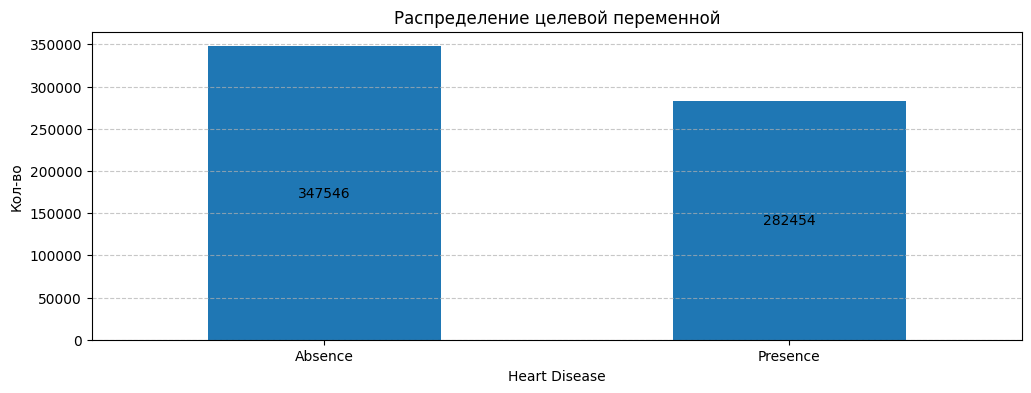

In [12]:
y_counts = train[target].value_counts()

def show_bar(data, title):
    ax = data.plot(
        kind='bar',
        title=title,
        ylabel='Кол-во',
        rot=0,
        figsize=(12, 4)
    )

    ax.bar_label(ax.containers[0], label_type='center')
    ax.grid(axis='y', linestyle='--', alpha=.7)

    plt.show()
    plt.close()

show_bar(y_counts, 'Распределение целевой переменной')

In [13]:
print(f'Доля Absence: {y_counts['Absence'] / y_desc['count'] * 100:.0f}%')
print(f'Доля Presence: {y_counts['Presence'] / y_desc['count'] * 100:.0f}%')

Доля Absence: 55%
Доля Presence: 45%


In [14]:
data = []

num_cols = []
cat_cols = []
for col in eda_df.columns:
    if col == target:
        continue

    nu = eda_df[col].nunique()
    data.append({
        'Признак': col,
        'Кол-во': nu
    })

    if nu > 5:
        num_cols.append(col)
    else:
        cat_cols.append(col)

pd.DataFrame(data).sort_values('Кол-во', ascending=False)

,Признак,Кол-во
4,Cholesterol,150
7,Max HR,93
3,BP,66
9,ST depression,66
0,Age,42
11,Number of vessels fluro,4
2,Chest pain type,4
10,Slope of ST,3
6,EKG results,3
12,Thallium,3


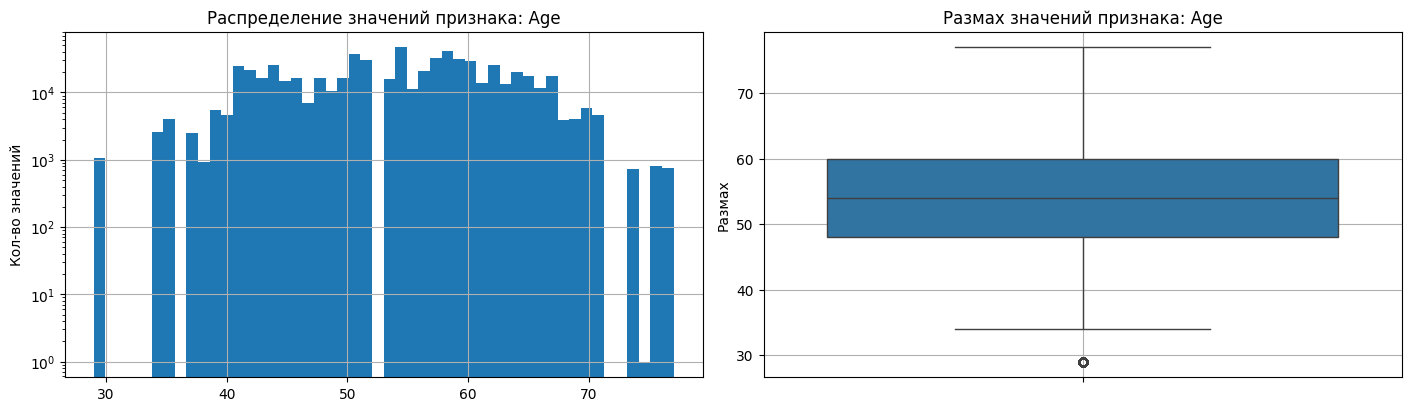

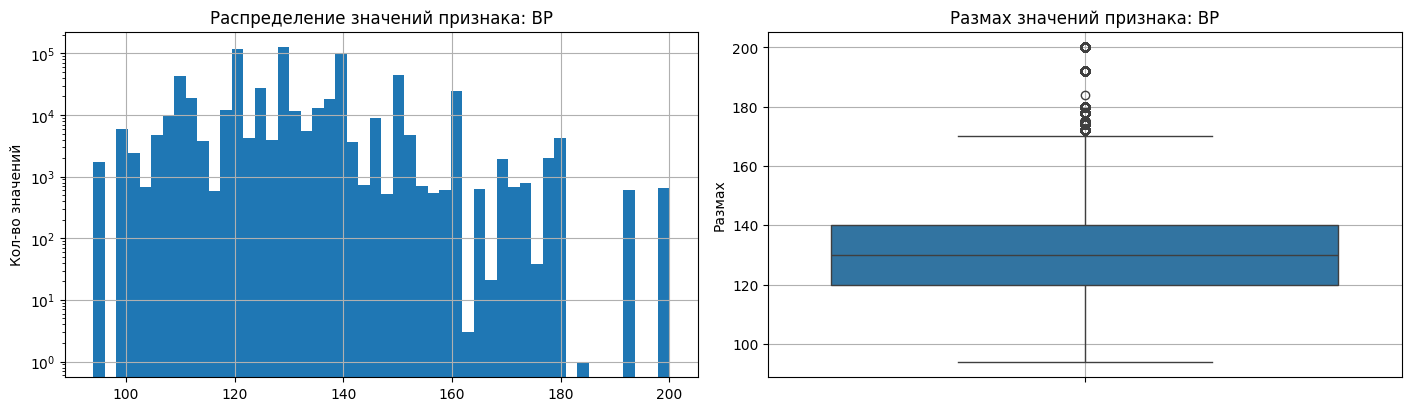

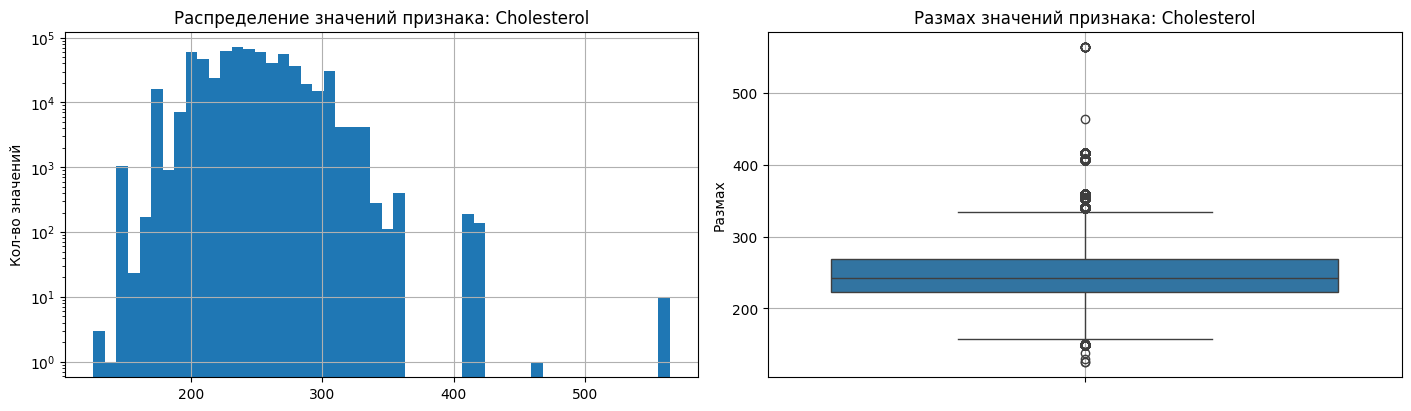

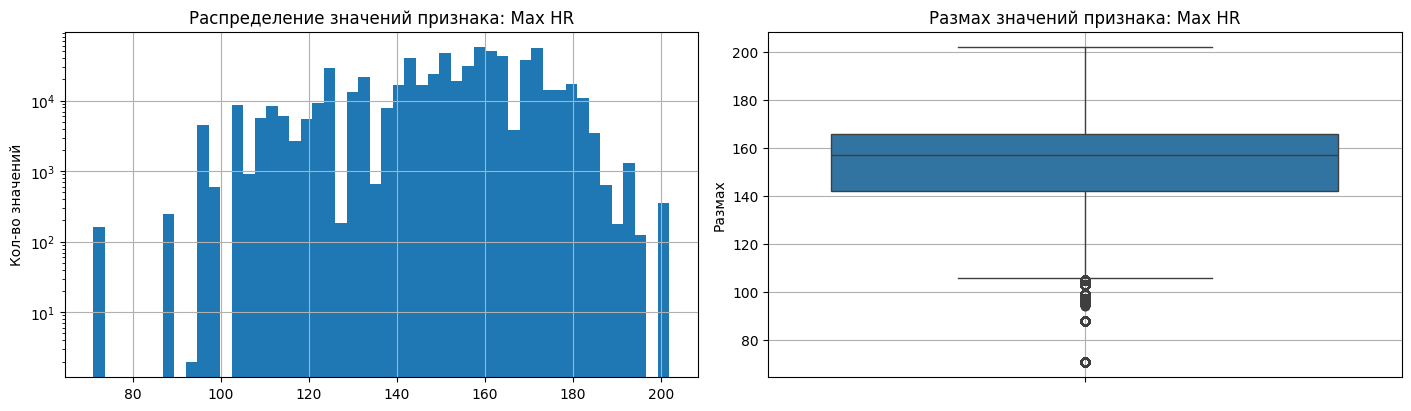

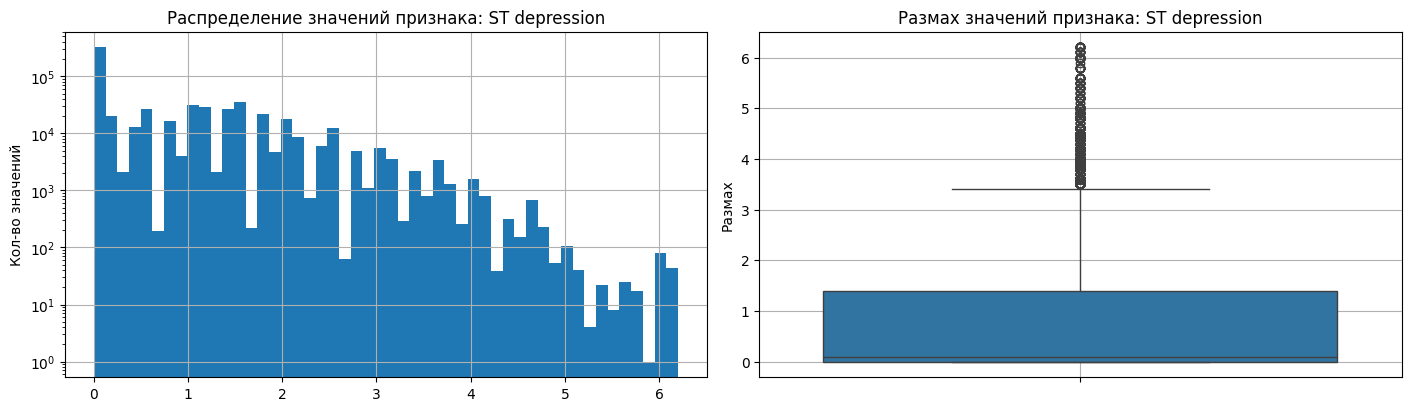

In [15]:
def show_boxplot(col, data, ax):
    sns.boxplot(data=data, ax=ax)

    ax.set_title(f'Размах значений признака: {col}')
    ax.set_ylabel('Размах')
    ax.grid(True)

def show_hist(col, data, ax):
    data.plot(
        kind='hist',
        bins=50,
        grid=True,
        ax=ax
    )

    ax.set_title(f'Распределение значений признака: {col}')
    ax.set_ylabel('Кол-во значений')
    ax.set_yscale('log')

def show_hist(col, data, ax):
    data.plot(
        kind='hist',
        bins=50,
        grid=True,
        ax=ax
    )

    ax.set_title(f'Распределение значений признака: {col}')
    ax.set_ylabel('Кол-во значений')
    ax.set_yscale('log')

for col in num_cols:
    _, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 4), constrained_layout=True)

    data = eda_df[col]
    show_hist(col, data, axes[0])
    show_boxplot(col, data, axes[1])

    plt.show()
    plt.close()


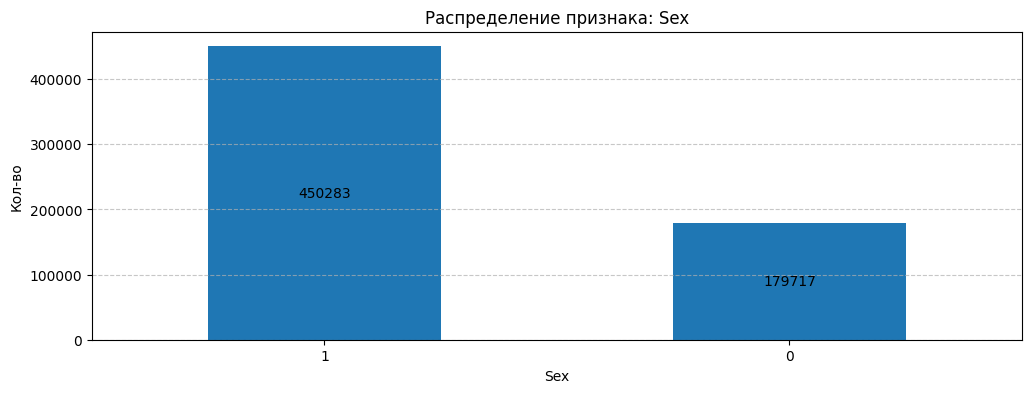

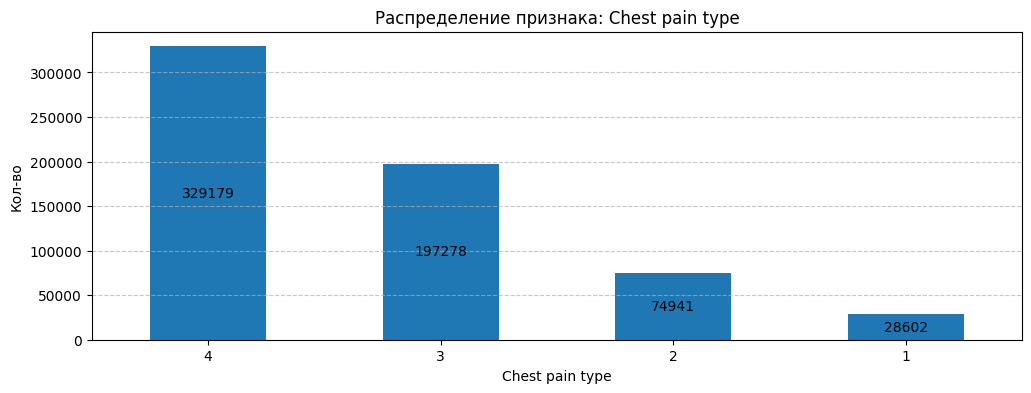

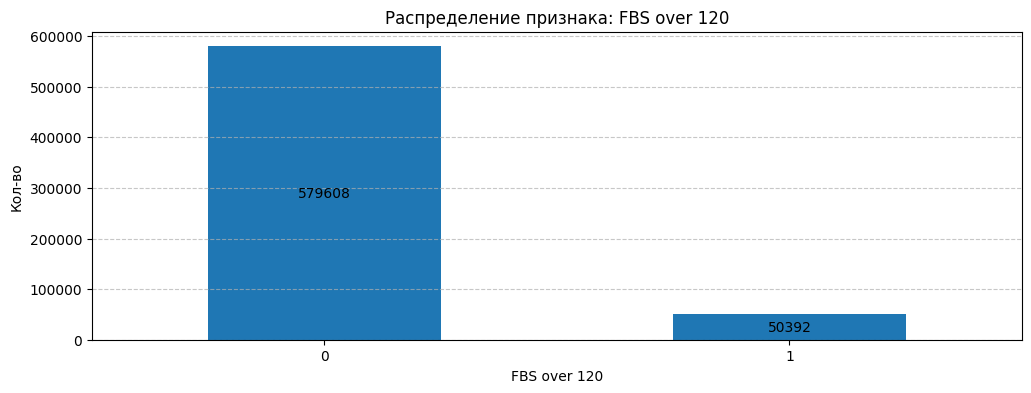

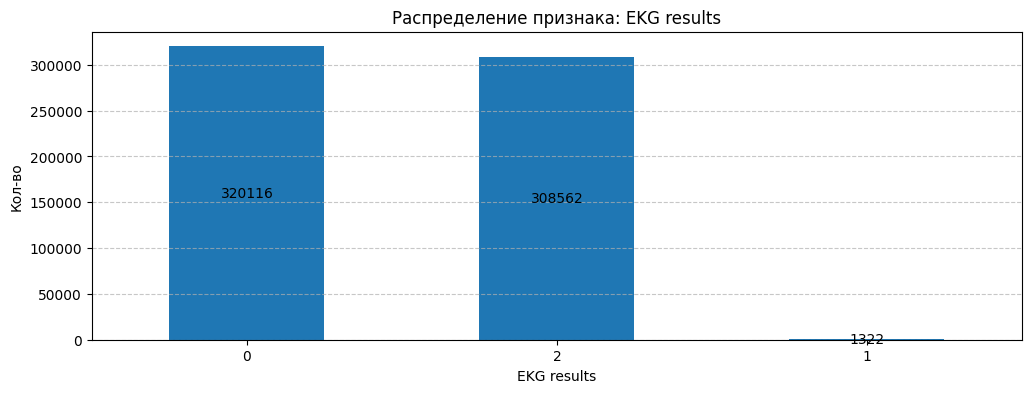

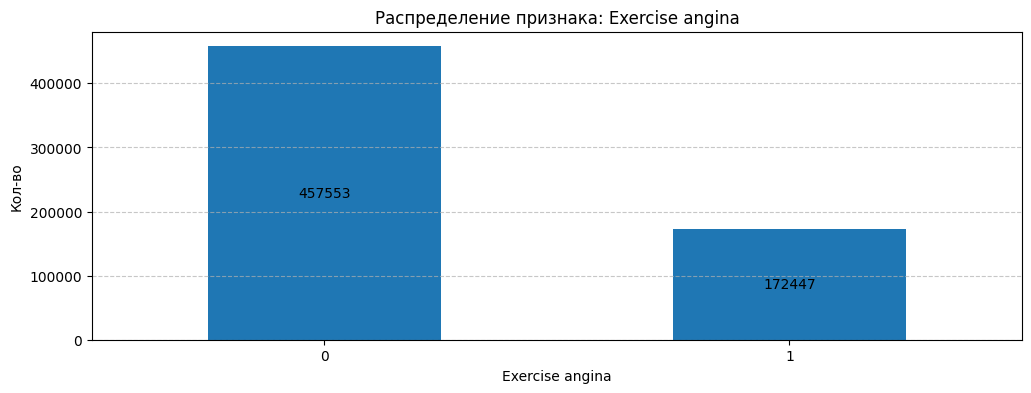

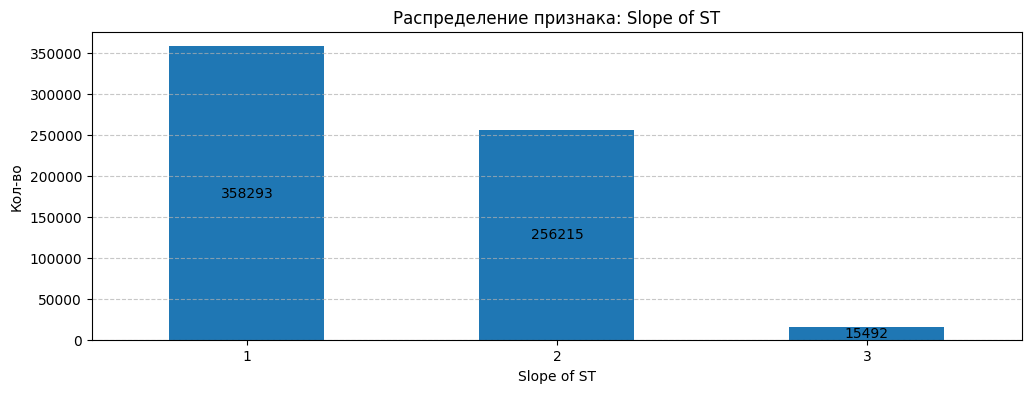

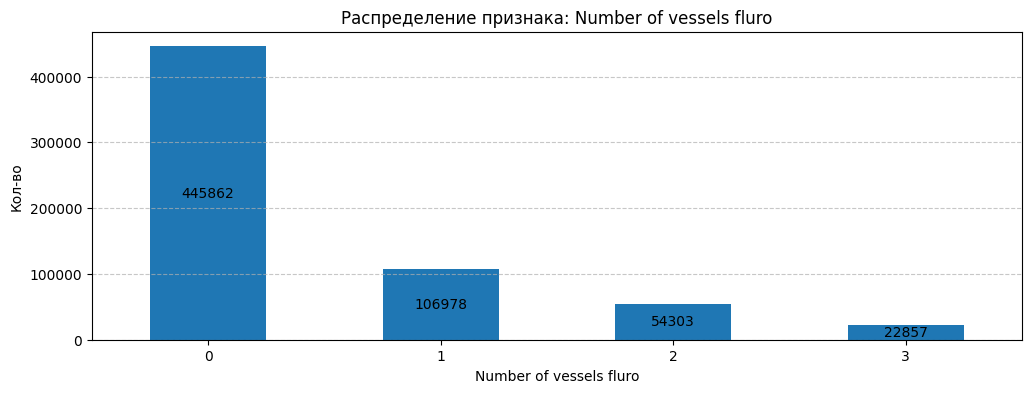

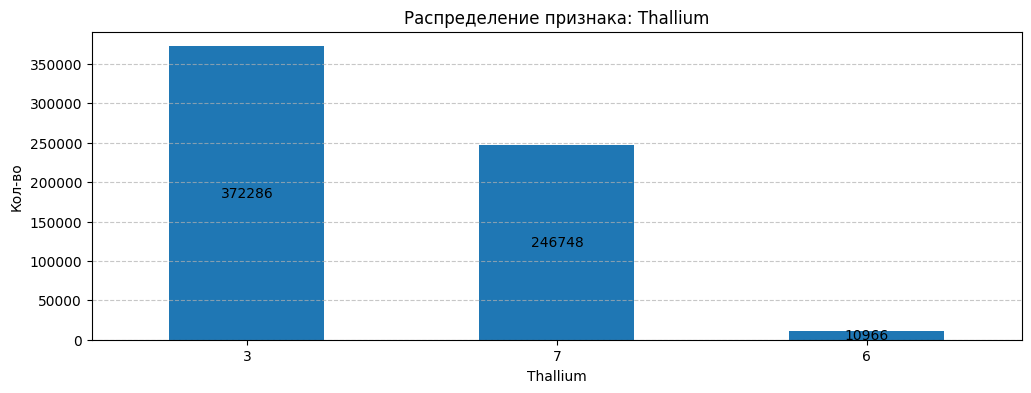

In [16]:
for col in cat_cols:
    show_bar(eda_df[col].value_counts(), f'Распределение признака: {col}')

In [17]:
def show_heatmap(corr, title, x, y_coef):
    num_rows = len(corr)
    dynamic_height = max(5, num_rows * y_coef)
    plt.figure(figsize=(x, dynamic_height))

    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        linewidth=.5,
        cbar=False
    )

    plt.title(title)
    plt.show()

In [18]:
nominal_cols = ['Chest pain type', 'EKG results', 'Thallium', 'Slope of ST']

In [19]:
mapping = {
    'Chest pain type': {
        1: 'Typical Angina', 2: 'Atypical Angina',
        3: 'Non-anginal Pain', 4: 'Asymptomatic'
    },
    'EKG results': {
        0: 'Normal', 1: 'ST-T Abnormality',
        2: 'LV Hypertrophy'
    },
    'Slope of ST': {
        1: 'Upsloping', 2: 'Flat', 3: 'Downsloping'
    },
    'Thallium': {
        3: 'Normal', 6: 'Fixed Defect', 7: 'Reversible Defect'
    }
}

for col, labels in mapping.items():
    if col in nominal_cols:
        eda_df[col] = eda_df[col].map(labels)

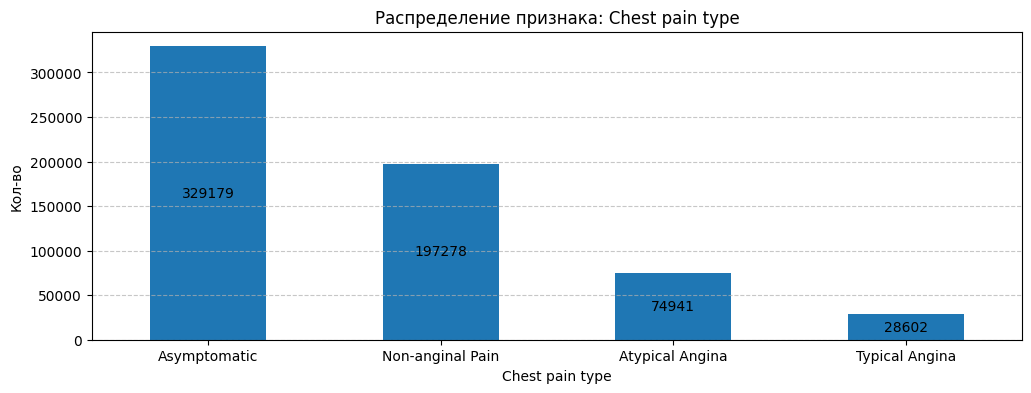

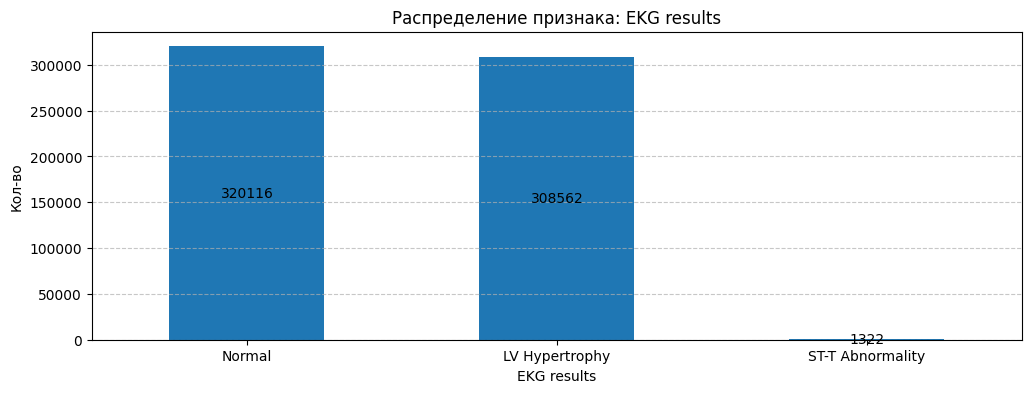

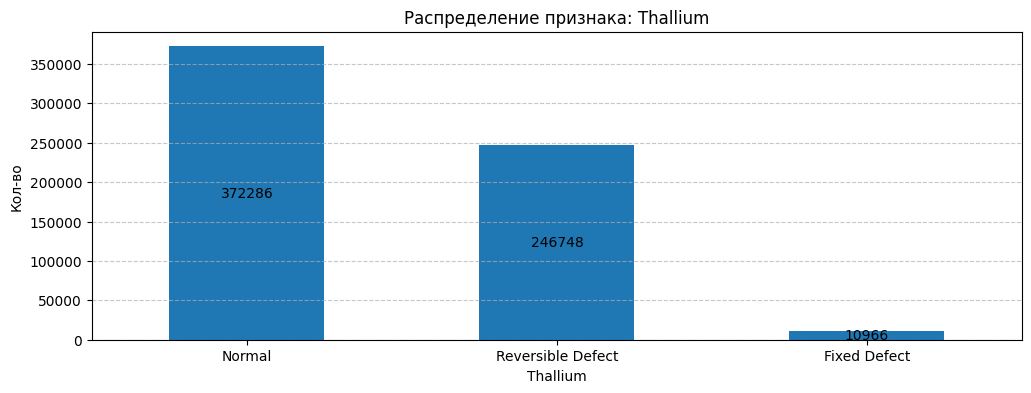

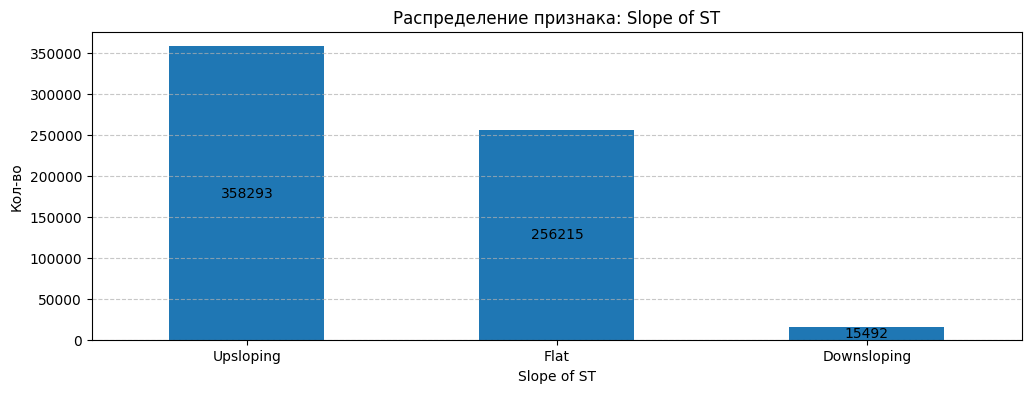

In [20]:
for col in nominal_cols:
    show_bar(eda_df[col].value_counts(), f'Распределение признака: {col}')

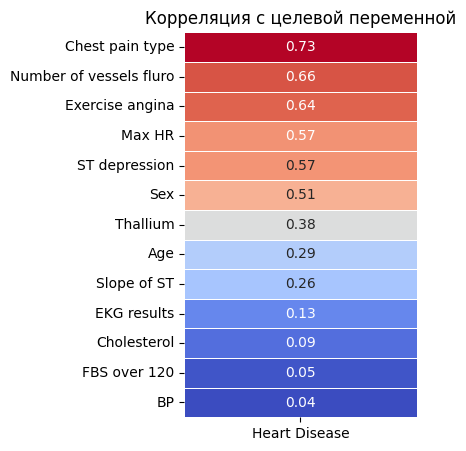

In [23]:
corr_matrix = eda_df.phik_matrix(interval_cols=['Age', 'Sex', 'BP', 'Cholesterol', 'FBS over 120', 'Max HR', 'Exercise angina', 'ST depression', 'Number of vessels fluro'])
target_corr = corr_matrix[corr_matrix.index != 'Heart Disease'][['Heart Disease']].sort_values('Heart Disease', ascending=False)

show_heatmap(target_corr, title='Корреляция с целевой переменной', x=3, y_coef=.1)

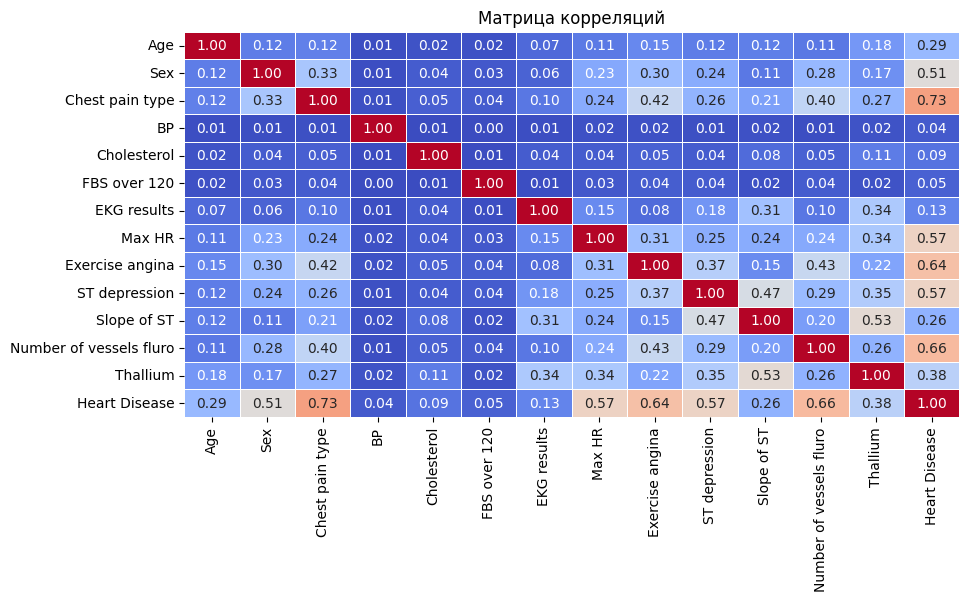

In [24]:
show_heatmap(corr_matrix, title='Матрица корреляций', x=10, y_coef=.3)

In [25]:
X = train.drop(columns=['Heart Disease'])
y = train['Heart Disease'].map({'Absence': 0, 'Presence': 1})

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    shuffle=True,
    test_size=.2,
    random_state=RANDOM_STATE
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Среднее значенее целевой переменной в train: {y_train.mean():.3f}")
print(f"Среднее значенее целевой переменной в test: {y_test.mean():.3f}")

Размер обучающей выборки: (504000, 13)
Размер тестовой выборки: (126000, 13)
Среднее значенее целевой переменной в train: 0.448
Среднее значенее целевой переменной в test: 0.448


In [60]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [45]:
results = []

In [46]:
def plot_classification_results(y_test, y_prob, y_pred, thresh=0.5, name="Model"):
    _, (ax_conf, ax_prob) = plt.subplots(1, 2, figsize=(16, 6))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_conf)
    ax_conf.set(
        title=f"{name} - Confusion Matrix",
        xlabel="Предсказанные метки",
        ylabel="Актуальные метки"
    )

    df_probs = pd.DataFrame({'Probability': y_prob, 'Actual': y_test})

    sns.histplot(data=df_probs, x='Probability', hue='Actual',
                 element='step', kde=True, bins=30, ax=ax_prob, palette='magma')

    ax_prob.axvline(thresh, color="red", linestyle="--", label=f'Порог {thresh:.2f}')
    ax_prob.set(
        title=f"{name} - Вероятностное распределение по классам",
        xlabel="Предполагаемая вероятность (1)",
        ylabel="Кол-во",
    )
    ax_prob.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

def show_ROC_curve(y_true, y_proba, score, name):
    fpr, tpr, _ = roc_curve(y_true, y_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-кривая (AUC = {score:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'ROC-кривая: {name}')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

def evaluate_model(pipeline, X_train, y_train, name="Model"):
    y_proba = cross_val_predict(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]
    score = roc_auc_score(y_train, y_proba)

    print(f"[{name}] ROC-AUC: {score:.4f}\n")
    show_ROC_curve(y_train, y_proba, score, name)

    y_pred = (y_proba >= .5).astype(int)
    print("Результаты на тесте с новым порогом")
    print(classification_report(y_train, y_pred, zero_division=0))

    plot_classification_results(y_train, y_proba, y_pred, name=name)

    results.append({
        'Название модели': name,
        'ROC-AUC': score
    })

In [47]:
def run_optuna(build_pipeline_fn, build_best_pipeline_fn, name, n_trials=30):
    def objective(trial):
        pipeline = build_pipeline_fn(trial)

        scores = cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring="roc_auc",
            n_jobs=-1
        )

        mean_score = scores.mean()

        trial.report(mean_score, step=0)
        if trial.should_prune():
            raise optuna.TrialPruned()

        return mean_score

    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True, n_jobs=-1)

    fig1 = optuna.visualization.plot_optimization_history(study)
    fig2 = optuna.visualization.plot_param_importances(study)

    display(fig1)
    display(fig2)

    best_params = study.best_params
    print("Лучшие гиперпараметры:", best_params)
    best_value = study.best_value
    print("Лучшее среднее значение ROC-AUC на кросс-валидации:", round(best_value, 3))

    evaluate_model(build_best_pipeline_fn(best_params), X_train, y_train, name=name)

    return best_params

In [48]:
base_linear_pipeline = Pipeline(steps=[
    ('preprocessor', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
])

[LogisticRegression [Baseline]] ROC-AUC: 0.9502



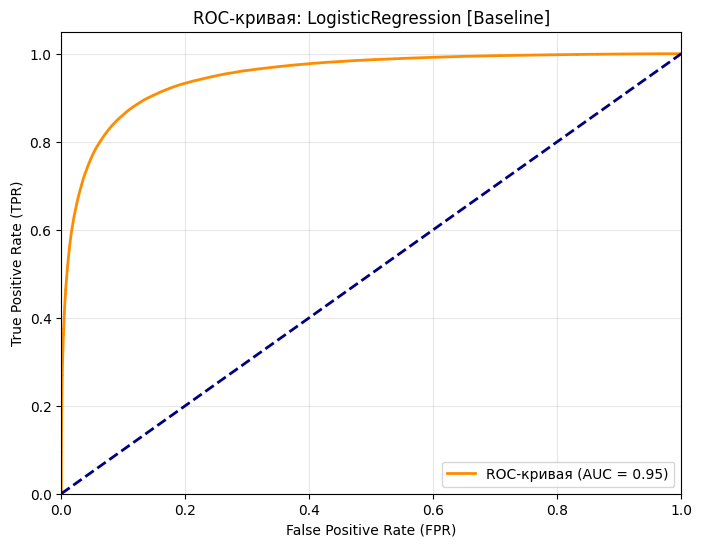

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.90      0.89      0.89    278037
           1       0.87      0.87      0.87    225963

    accuracy                           0.88    504000
   macro avg       0.88      0.88      0.88    504000
weighted avg       0.88      0.88      0.88    504000



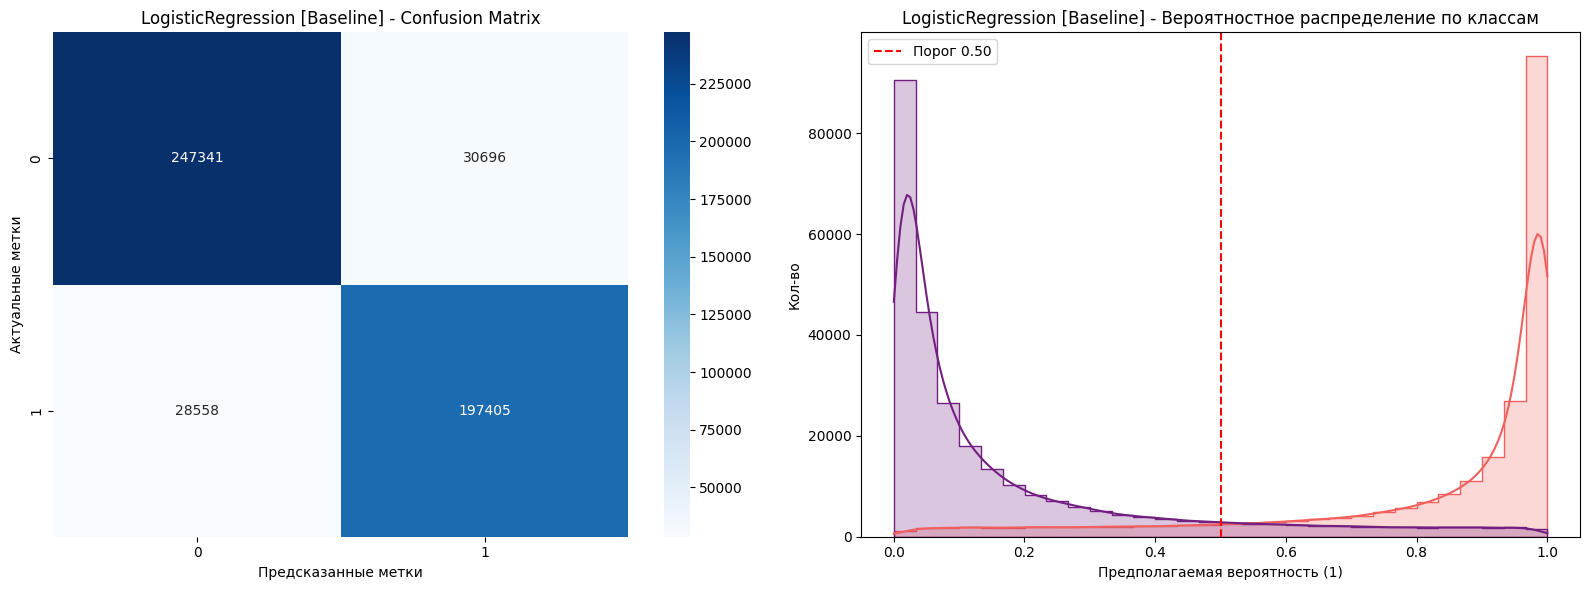

In [49]:
evaluate_model(base_linear_pipeline, X_train, y_train, name='LogisticRegression [Baseline]')

In [50]:
upd_num_cols = [col for col in num_cols if col not in cat_cols]

In [51]:
def medical_mapping_transformer(X):
    X_copy = X.copy()

    for col, labels in mapping.items():
        if col in X_copy.columns:
            X_copy[col] = X_copy[col].map(labels)

    return X_copy

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', make_pipeline(
            FunctionTransformer(medical_mapping_transformer, feature_names_out="one-to-one"),
            OneHotEncoder(drop='first', sparse_output=False)
        ), nominal_cols),
        ('num', StandardScaler(), upd_num_cols)
    ]
).set_output(transform="pandas")

X_transformed_df = preprocessor.fit_transform(X_train)
X_transformed_df.head()

,cat__Chest pain type_Atypical Angina,cat__Chest pain type_Non-anginal Pain,cat__Chest pain type_Typical Angina,cat__EKG results_Normal,cat__EKG results_ST-T Abnormality,cat__Thallium_Normal,cat__Thallium_Reversible Defect,cat__Slope of ST_Flat,cat__Slope of ST_Upsloping,num__Age,num__BP,num__Cholesterol,num__Max HR,num__ST depression
539041,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,-0.742957,0.633697,0.118095,-0.460866,1.880191
211140,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.830778,-0.033975,-1.098852,1.108459,0.931544
325129,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.799231,-0.033975,-0.564583,-1.088596,0.720733
91177,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.557118,0.633697,0.711727,1.526946,0.509923
346105,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,-0.742957,-0.701647,0.889817,0.951527,-0.333319


[LogisticRegression [Baseline with upd pipe]] ROC-AUC: 0.9381



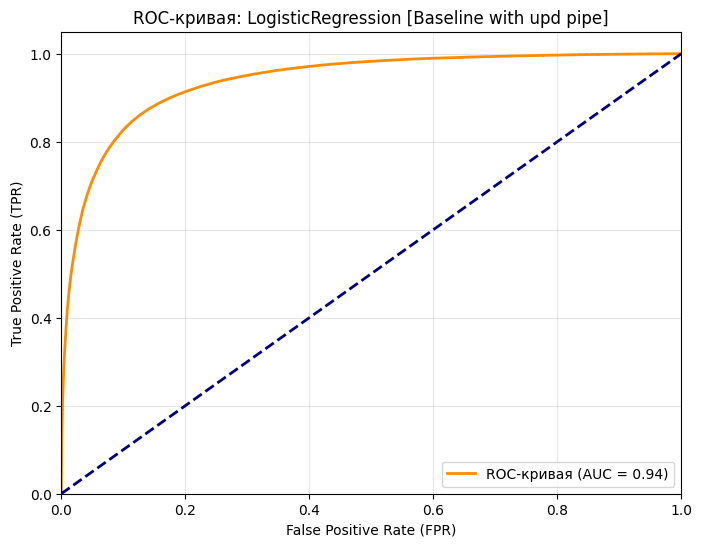

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.89      0.87      0.88    278037
           1       0.85      0.86      0.85    225963

    accuracy                           0.87    504000
   macro avg       0.87      0.87      0.87    504000
weighted avg       0.87      0.87      0.87    504000



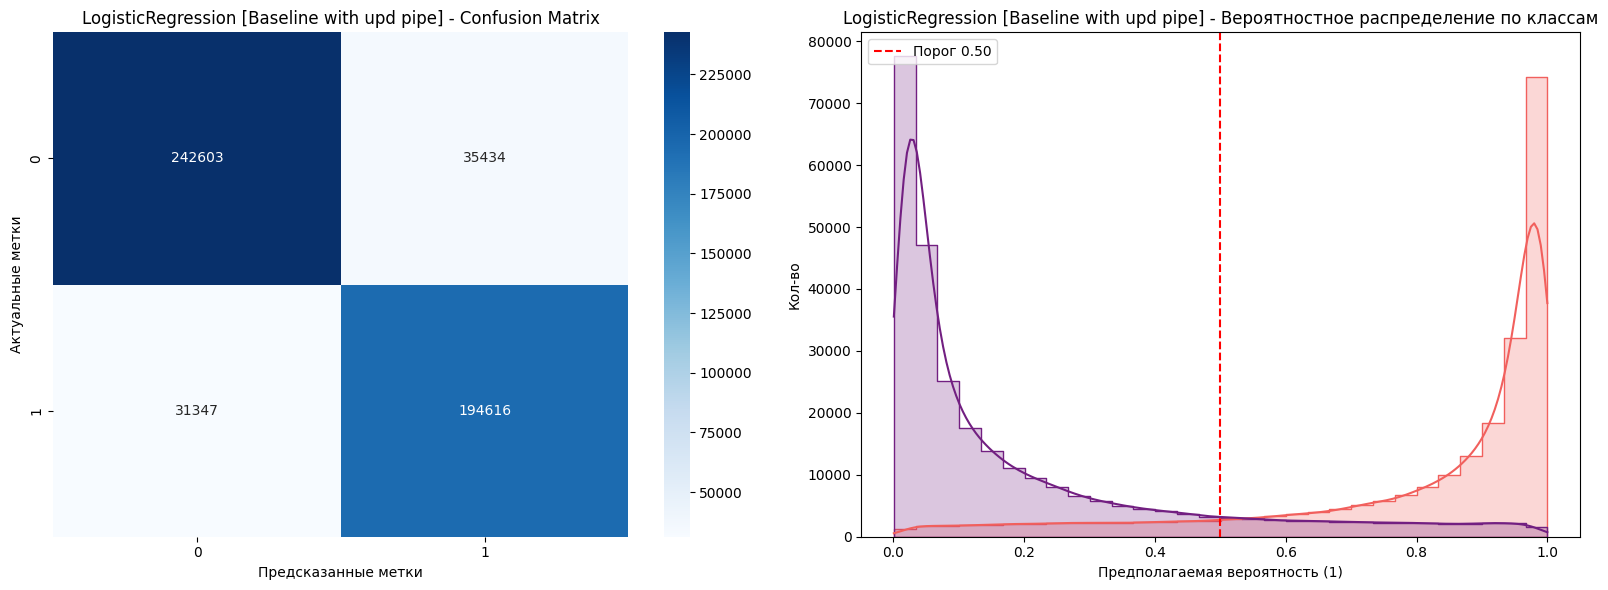

In [52]:
upd_linear_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
])

evaluate_model(upd_linear_pipeline, X_train, y_train, name='LogisticRegression [Baseline with upd pipe]')

[I 2026-02-15 11:41:41,445] A new study created in memory with name: no-name-93f5214f-67ff-41e7-9860-31347f1ded7e


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-02-15 11:42:09,313] Trial 0 finished with value: 0.9502302596578888 and parameters: {'class_weight': 'balanced', 'tol': 0.0029106359131330704, 'max_iter': 12776, 'solver': 'saga', 'C': 0.4042872735027334, 'l1_ratio': 0.7080725777960455}. Best is trial 0 with value: 0.9502302596578888.
[I 2026-02-15 11:42:37,218] Trial 1 finished with value: 0.9502304037862161 and parameters: {'class_weight': 'balanced', 'tol': 0.004622589001020831, 'max_iter': 5822, 'solver': 'saga', 'C': 0.039054412752107935, 'l1_ratio': 0.2912291401980419}. Best is trial 1 with value: 0.9502304037862161.
[I 2026-02-15 11:42:43,551] Trial 2 finished with value: 0.9502250412009967 and parameters: {'class_weight': None, 'tol': 0.0003839629299804173, 'max_iter': 8594, 'solver': 'newton-cg', 'C': 0.35849855803404745}. Best is trial 1 with value: 0.9502304037862161.
[I 2026-02-15 11:42:50,085] Trial 3 finished with value: 0.9502224467620071 and parameters: {'class_weight': 'balanced', 'tol': 0.00021930485556643703,

Лучшие гиперпараметры: {'class_weight': 'balanced', 'tol': 0.00012315571723666037, 'max_iter': 7856, 'solver': 'newton-cholesky', 'C': 0.0048484961838732915}
Лучшее среднее значение ROC-AUC на кросс-валидации: 0.95
[LogisticRegression [Best Params]] ROC-AUC: 0.9502



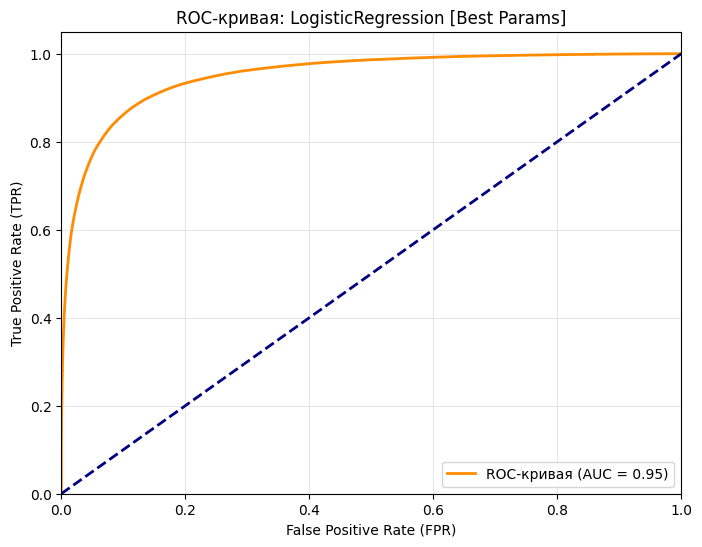

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.90      0.89      0.89    278037
           1       0.87      0.87      0.87    225963

    accuracy                           0.88    504000
   macro avg       0.88      0.88      0.88    504000
weighted avg       0.88      0.88      0.88    504000



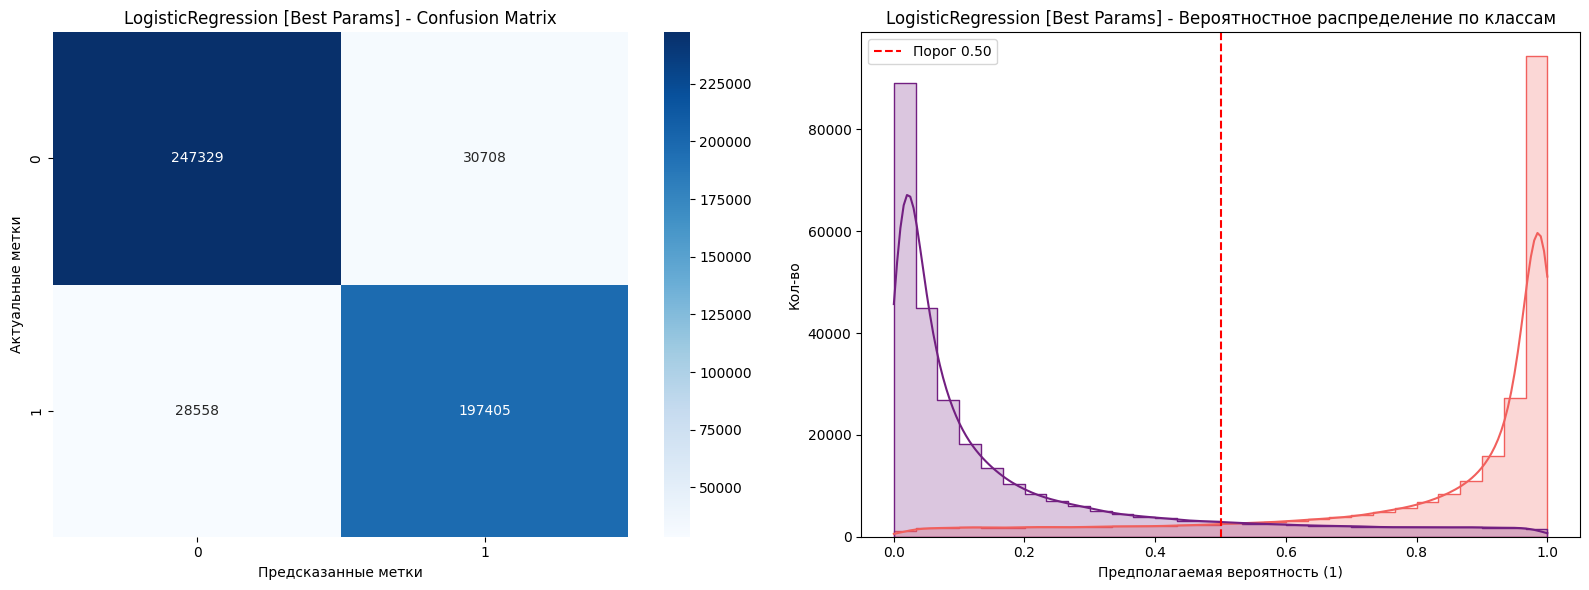

In [53]:
def build_pipeline_fn(trial):
    params = {
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "fit_intercept": True,
        "tol": trial.suggest_float("tol", 1e-4, 1e-2, log=True),
        "max_iter": trial.suggest_int("max_iter", 2000, 20000),
        "solver": trial.suggest_categorical("solver", ["lbfgs", "newton-cg", "newton-cholesky", "saga"]),
        "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
        "random_state": RANDOM_STATE,
    }

    solver = params["solver"]
    if solver in ["lbfgs", "newton-cg", "newton-cholesky"]:
        params["l1_ratio"] = 0
    elif solver == "saga":
        params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.0, 1.0)

    model = LogisticRegression(**params)
    pipeline = Pipeline(steps=[
        ('preprocessor', StandardScaler()),
        ('model', model)
    ])

    return pipeline

def build_best_pipeline_fn(best_params):
    pipeline = Pipeline(steps=[
        ("preprocessor", StandardScaler()),
        ("model", LogisticRegression(**best_params, random_state=RANDOM_STATE, n_jobs=-1))
    ])
    return pipeline

lr_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "LogisticRegression [Best Params]", n_trials=100)

[I 2026-02-15 11:44:46,760] A new study created in memory with name: no-name-2621ebbd-c435-4a12-8d17-0d41fc31f3d3


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-02-15 11:45:19,689] Trial 0 finished with value: 0.9381175295350734 and parameters: {'class_weight': 'balanced', 'tol': 0.0029106359131330704, 'max_iter': 12776, 'solver': 'saga', 'C': 0.4042872735027334, 'l1_ratio': 0.7080725777960455}. Best is trial 0 with value: 0.9381175295350734.
[I 2026-02-15 11:45:49,460] Trial 1 finished with value: 0.938115294316086 and parameters: {'class_weight': 'balanced', 'tol': 0.004622589001020831, 'max_iter': 5822, 'solver': 'saga', 'C': 0.039054412752107935, 'l1_ratio': 0.2912291401980419}. Best is trial 0 with value: 0.9381175295350734.
[I 2026-02-15 11:46:11,315] Trial 2 finished with value: 0.9381159395975966 and parameters: {'class_weight': None, 'tol': 0.0003839629299804173, 'max_iter': 8594, 'solver': 'newton-cg', 'C': 0.35849855803404745}. Best is trial 0 with value: 0.9381175295350734.
[I 2026-02-15 11:46:30,534] Trial 3 finished with value: 0.9356806123000242 and parameters: {'class_weight': 'balanced', 'tol': 0.00021930485556643703, 

Лучшие гиперпараметры: {'class_weight': 'balanced', 'tol': 0.0029106359131330704, 'max_iter': 12776, 'solver': 'saga', 'C': 0.4042872735027334, 'l1_ratio': 0.7080725777960455}
Лучшее среднее значение ROC-AUC на кросс-валидации: 0.938
[LogisticRegression [Best Params with upd pipe]] ROC-AUC: 0.9381



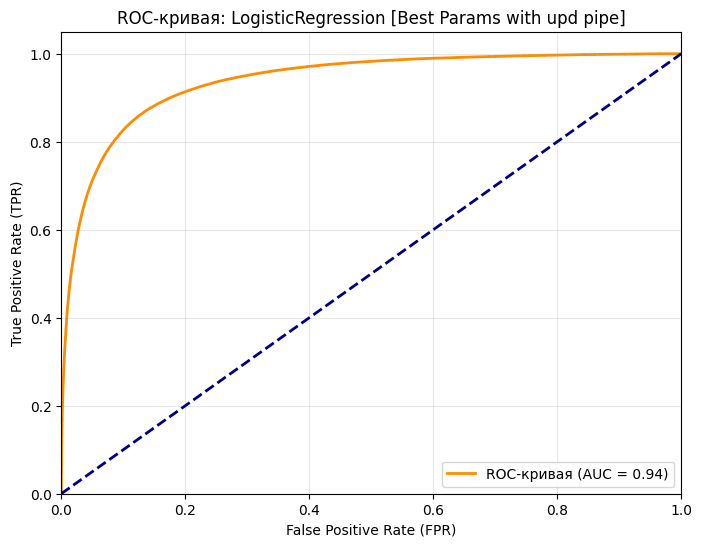

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.89      0.87      0.88    278037
           1       0.85      0.86      0.85    225963

    accuracy                           0.87    504000
   macro avg       0.87      0.87      0.87    504000
weighted avg       0.87      0.87      0.87    504000



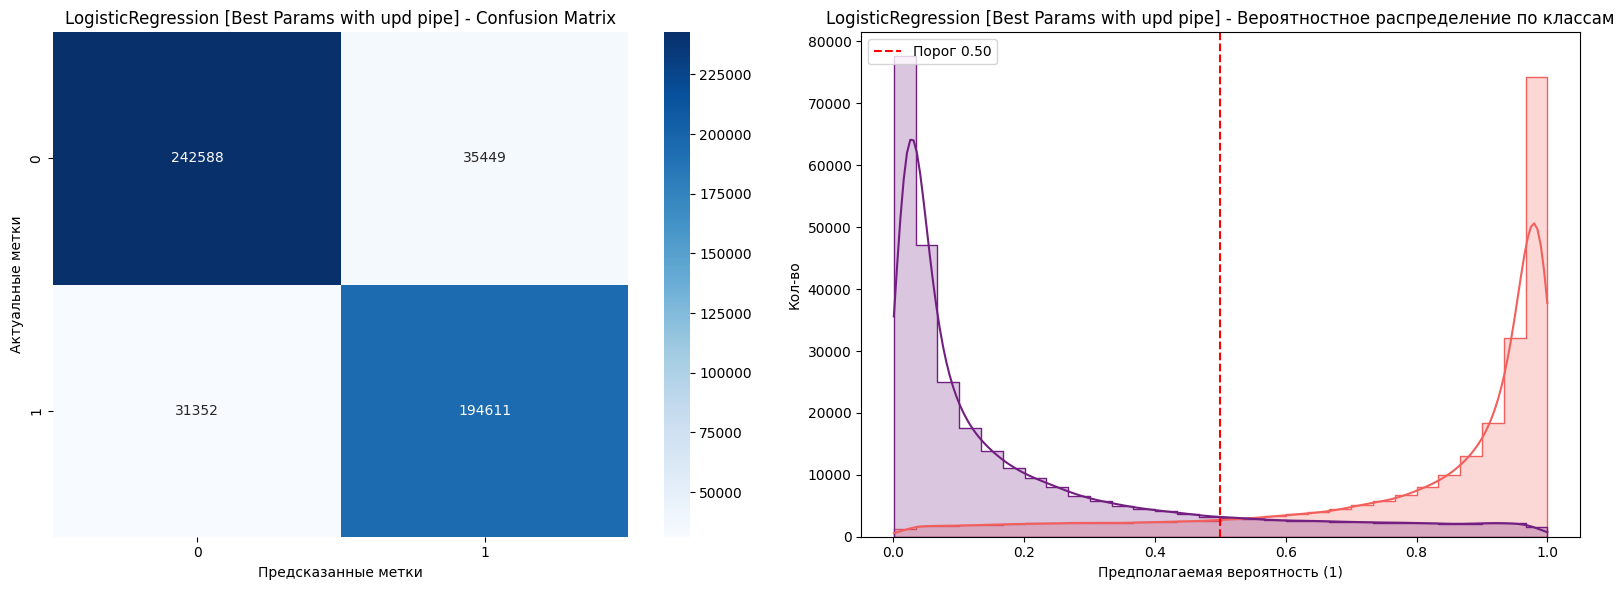

In [54]:
def build_pipeline_fn(trial):
    params = {
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "fit_intercept": True,
        "tol": trial.suggest_float("tol", 1e-4, 1e-2, log=True),
        "max_iter": trial.suggest_int("max_iter", 2000, 20000),
        "solver": trial.suggest_categorical("solver", ["lbfgs", "newton-cg", "newton-cholesky", "saga"]),
        "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
        "random_state": RANDOM_STATE,
    }

    solver = params["solver"]
    if solver in ["lbfgs", "newton-cg", "newton-cholesky"]:
        params["l1_ratio"] = 0
    elif solver == "saga":
        params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.0, 1.0)

    model = LogisticRegression(**params)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    return pipeline

def build_best_pipeline_fn(best_params):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(**best_params, random_state=RANDOM_STATE, n_jobs=-1))
    ])
    return pipeline

lr_up_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "LogisticRegression [Best Params with upd pipe]", n_trials=100)

[Tree [Baseline]] ROC-AUC: 0.8237



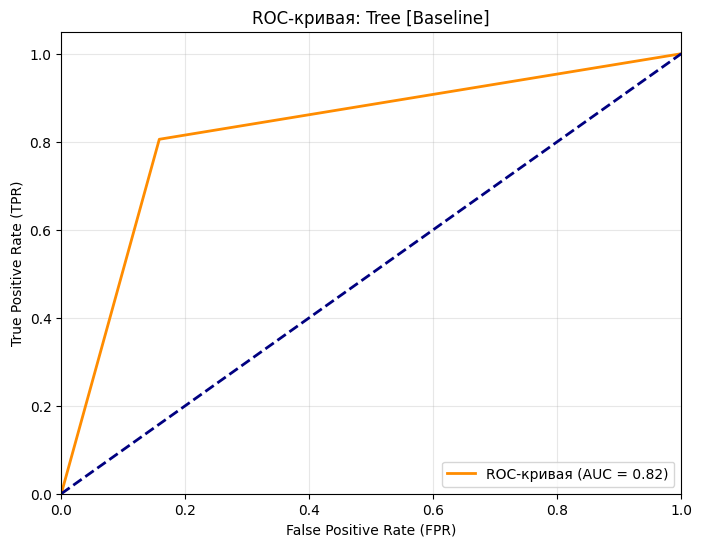

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.84      0.84      0.84    278037
           1       0.81      0.81      0.81    225963

    accuracy                           0.83    504000
   macro avg       0.82      0.82      0.82    504000
weighted avg       0.83      0.83      0.83    504000



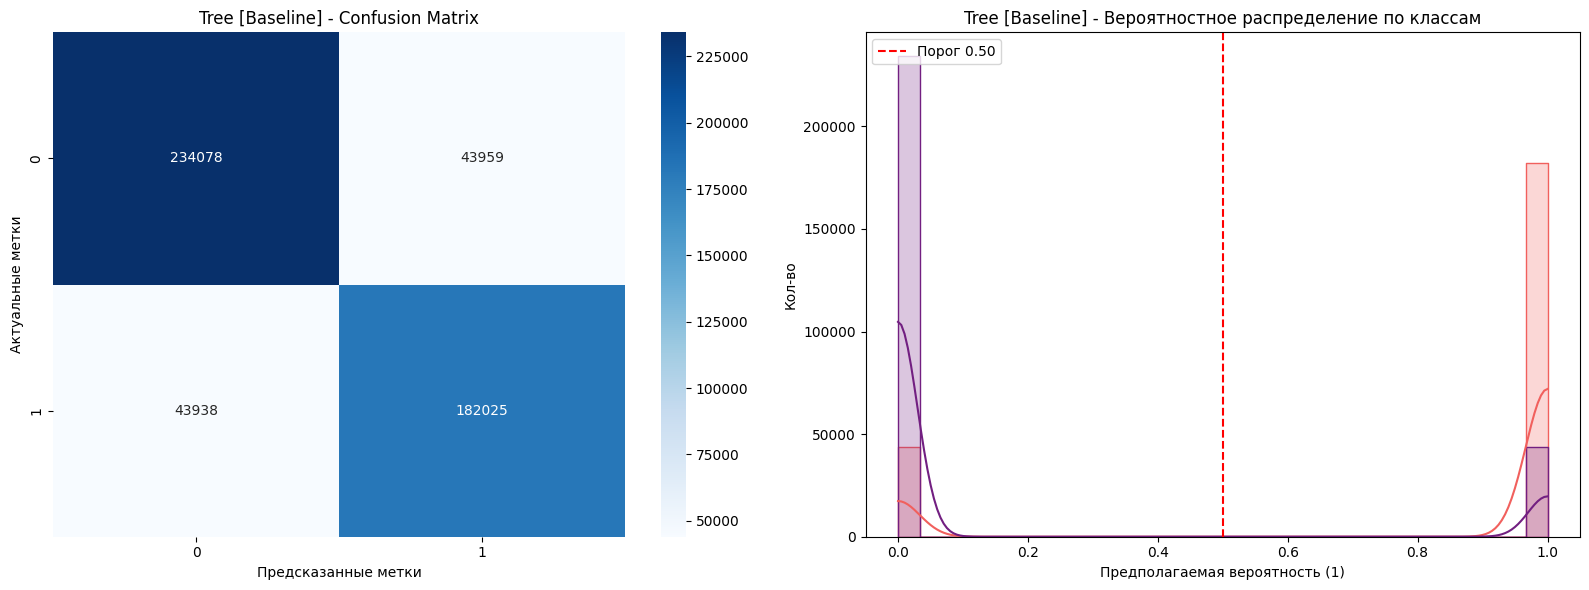

In [55]:
evaluate_model(DecisionTreeClassifier(class_weight='balanced'), X_train, y_train, name='Tree [Baseline]')

[I 2026-02-15 11:52:41,651] A new study created in memory with name: no-name-6817021e-2330-4541-8ec7-f6faed86fb42


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-02-15 11:53:09,494] Trial 0 finished with value: 0.94975020342766 and parameters: {'criterion': 'log_loss', 'max_depth': 12, 'min_samples_leaf': 40, 'min_samples_split': 40, 'min_impurity_decrease': 2.2853255256339197e-05, 'ccp_alpha': 1.4347159517201392e-05}. Best is trial 0 with value: 0.94975020342766.
[I 2026-02-15 11:53:35,431] Trial 1 finished with value: 0.9386884126416435 and parameters: {'criterion': 'entropy', 'max_depth': 12, 'min_samples_leaf': 11, 'min_samples_split': 147, 'min_impurity_decrease': 0.0008231433730995545, 'ccp_alpha': 3.7419406111184946e-05}. Best is trial 0 with value: 0.94975020342766.
[I 2026-02-15 11:53:55,889] Trial 2 finished with value: 0.9412626698220471 and parameters: {'criterion': 'log_loss', 'max_depth': 7, 'min_samples_leaf': 36, 'min_samples_split': 76, 'min_impurity_decrease': 4.678719265016204e-05, 'ccp_alpha': 0.0004480975918214954}. Best is trial 0 with value: 0.94975020342766.
[I 2026-02-15 11:54:19,170] Trial 3 finished with value

Лучшие гиперпараметры: {'criterion': 'log_loss', 'max_depth': 12, 'min_samples_leaf': 40, 'min_samples_split': 40, 'min_impurity_decrease': 2.2853255256339197e-05, 'ccp_alpha': 1.4347159517201392e-05}
Лучшее среднее значение ROC-AUC на кросс-валидации: 0.95
[Tree [Best Params]] ROC-AUC: 0.9497



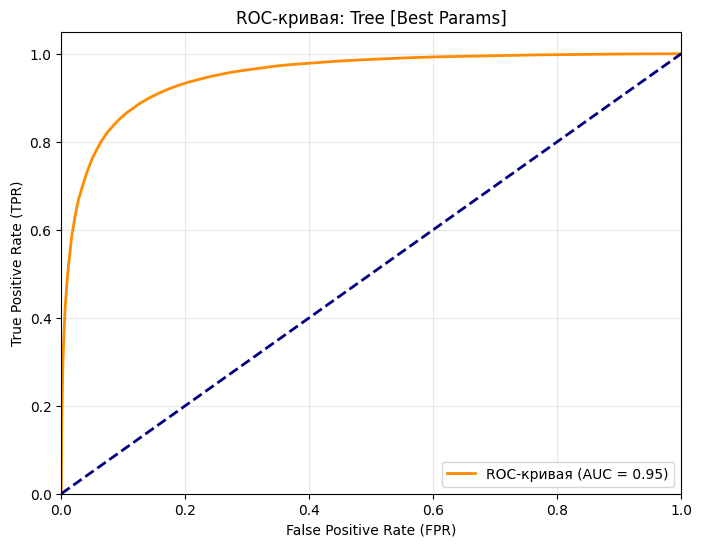

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.89      0.90      0.89    278037
           1       0.88      0.86      0.87    225963

    accuracy                           0.88    504000
   macro avg       0.88      0.88      0.88    504000
weighted avg       0.88      0.88      0.88    504000



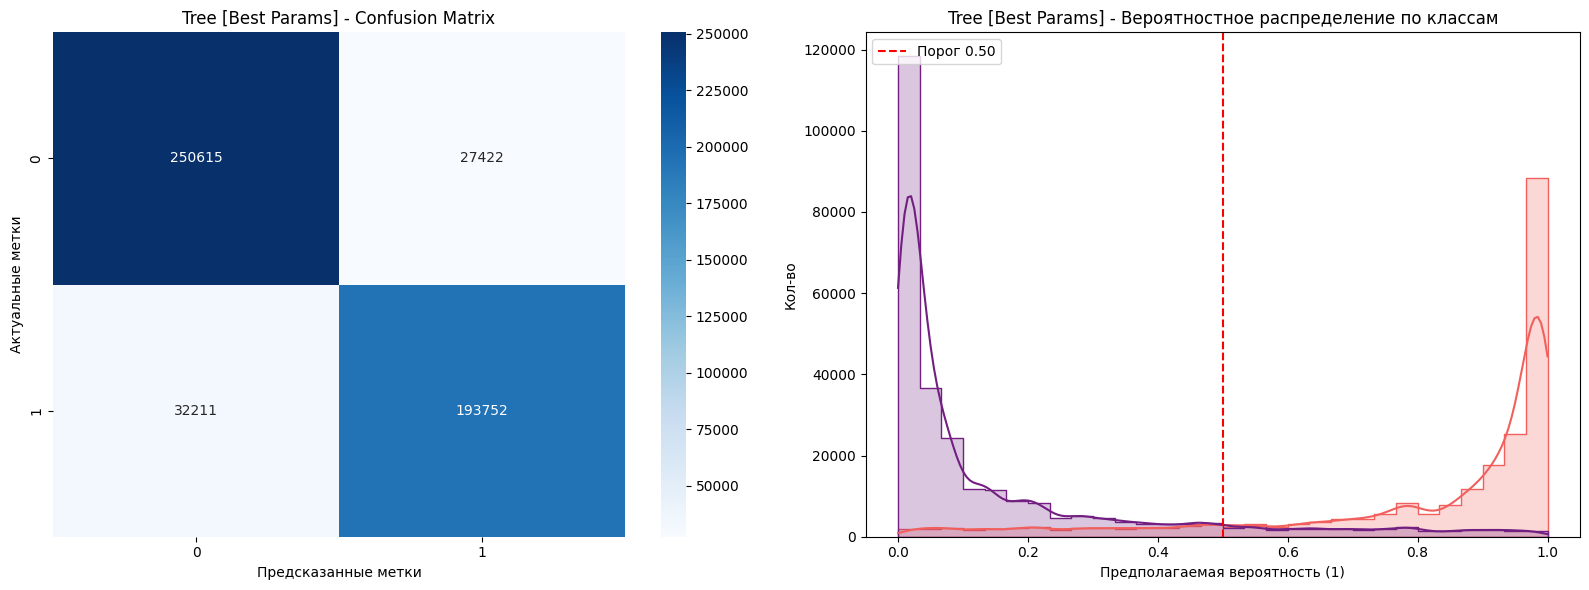

In [56]:
def build_pipeline_fn(trial):
    params = {
        "criterion": trial.suggest_categorical("criterion", ["entropy", "log_loss"]),
        "splitter": "best",
        "max_depth": trial.suggest_int("max_depth", 4, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 60),
        "min_samples_split": trial.suggest_int("min_samples_split", 20, 150),
        "max_features": None,
        "min_impurity_decrease": trial.suggest_float("min_impurity_decrease", 1e-5, 2e-3, log=True),
        "ccp_alpha": trial.suggest_float("ccp_alpha", 1e-5, 5e-3, log=True),
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }

    return DecisionTreeClassifier(**params)

def build_best_pipeline_fn(best_params):
    return DecisionTreeClassifier(**best_params)

tree_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Tree [Best Params]", n_trials=50)

[I 2026-02-15 12:33:55,234] A new study created in memory with name: no-name-0882c8f1-223f-4fb9-b50e-95b31733ca8e


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-02-15 12:35:11,492] Trial 0 finished with value: 0.9463973864851611 and parameters: {'n_estimators': 56, 'max_depth': 15, 'min_samples_leaf': 160, 'min_samples_split': 200, 'max_features': 'sqrt', 'max_samples': 0.47323522915498706, 'min_impurity_decrease': 0.00025378155082656634, 'ccp_alpha': 0.0006796578090758161}. Best is trial 0 with value: 0.9463973864851611.
[I 2026-02-15 12:35:40,170] Trial 1 finished with value: 0.9490636425315723 and parameters: {'n_estimators': 31, 'max_depth': 15, 'min_samples_leaf': 175, 'min_samples_split': 103, 'max_features': 0.3, 'max_samples': 0.40495128632644756, 'min_impurity_decrease': 5.34293726127978e-05, 'ccp_alpha': 1.461896279370496e-05}. Best is trial 1 with value: 0.9490636425315723.
[I 2026-02-15 12:36:35,014] Trial 2 finished with value: 0.9475938803250156 and parameters: {'n_estimators': 73, 'max_depth': 6, 'min_samples_leaf': 94, 'min_samples_split': 141, 'max_features': 'log2', 'max_samples': 0.4028468876827223, 'min_impurity_dec

Лучшие гиперпараметры: {'n_estimators': 68, 'max_depth': 13, 'min_samples_leaf': 143, 'min_samples_split': 166, 'max_features': 'log2', 'max_samples': 0.3641629887348248, 'min_impurity_decrease': 1.017744221332265e-06, 'ccp_alpha': 1.0757588226877118e-06}
Лучшее среднее значение ROC-AUC на кросс-валидации: 0.951
[Random Forest [Best Params]] ROC-AUC: 0.9510



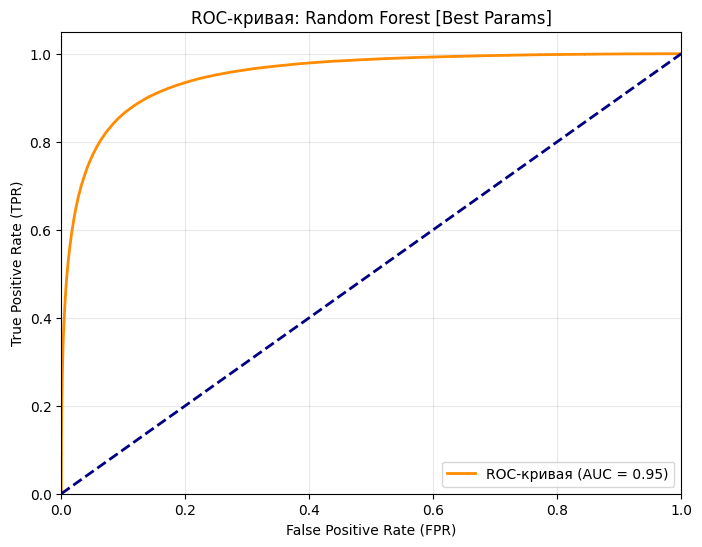

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.89      0.90      0.90    278037
           1       0.88      0.86      0.87    225963

    accuracy                           0.88    504000
   macro avg       0.88      0.88      0.88    504000
weighted avg       0.88      0.88      0.88    504000



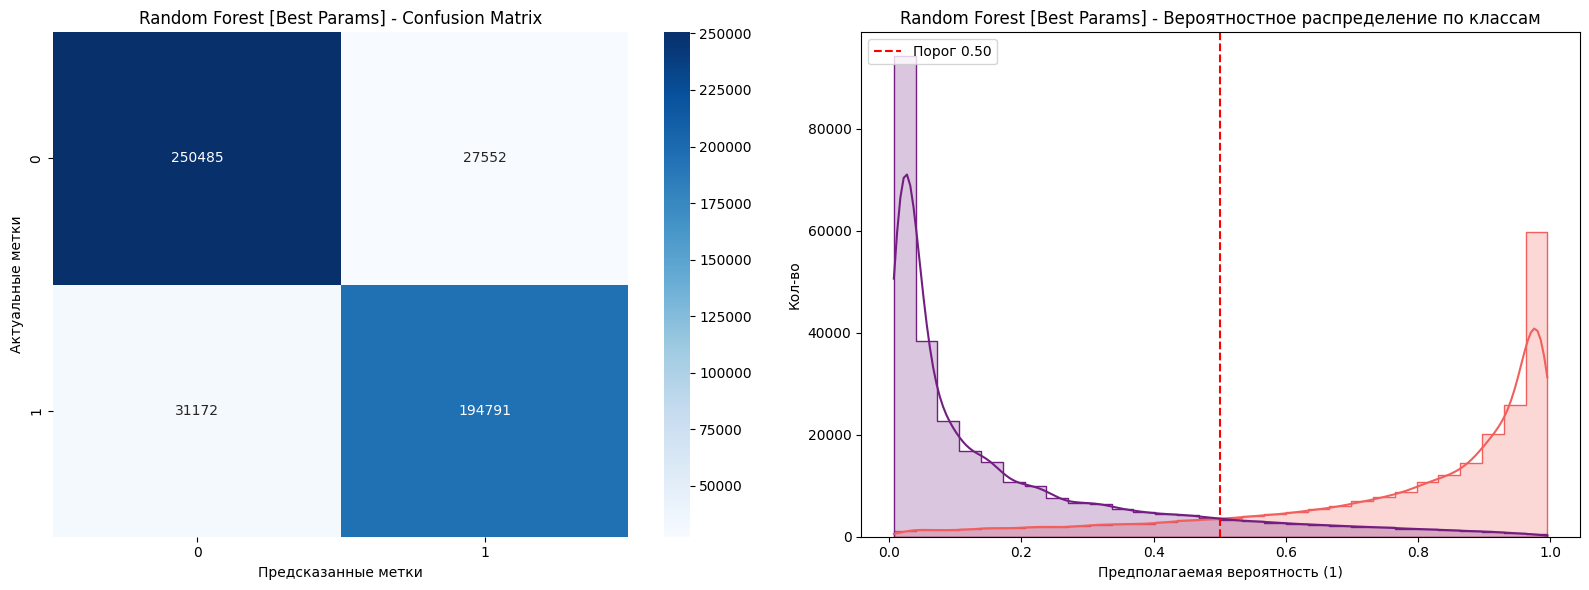

In [62]:
def build_pipeline_fn(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 30, 100),
        "max_depth": trial.suggest_int("max_depth", 5, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 50, 200),
        "min_samples_split": trial.suggest_int("min_samples_split", 50, 300),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3]),
        "bootstrap": True,
        "max_samples": trial.suggest_float("max_samples", 0.3, 0.5),
        "min_impurity_decrease": trial.suggest_float("min_impurity_decrease", 1e-6, 1e-2, log=True),
        "ccp_alpha": trial.suggest_float("ccp_alpha", 1e-6, 1e-2, log=True),
        "criterion": "gini",
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }

    return RandomForestClassifier(**params)

def build_best_pipeline_fn(best_params):
    return RandomForestClassifier(**best_params)

rf_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Random Forest [Best Params]", n_trials=50)

[Cat Boost [Baseline]] ROC-AUC: 0.9548



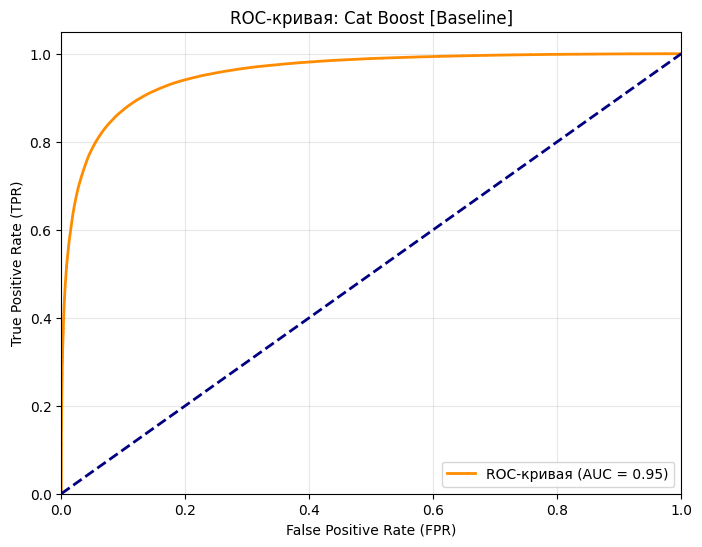

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.90      0.89      0.90    278037
           1       0.87      0.88      0.88    225963

    accuracy                           0.89    504000
   macro avg       0.89      0.89      0.89    504000
weighted avg       0.89      0.89      0.89    504000



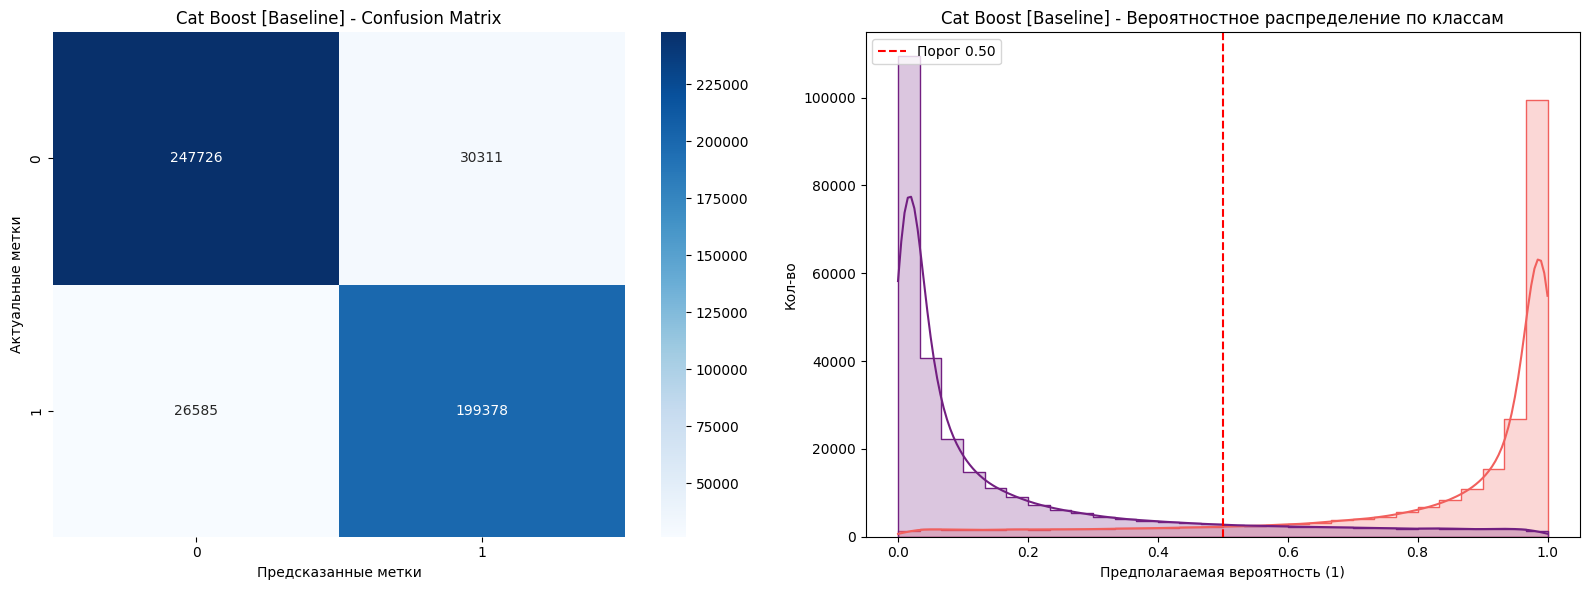

In [63]:
evaluate_model(CatBoostClassifier(auto_class_weights='Balanced', thread_count=-1, random_state=RANDOM_STATE), X_train, y_train, name='Cat Boost [Baseline]')

[I 2026-02-15 13:06:24,310] A new study created in memory with name: no-name-5ec5ca66-7b0a-4f21-a6cc-07c87bf1dd45


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-02-15 13:07:14,453] Trial 0 finished with value: 0.9543112413140615 and parameters: {'bootstrap_type': 'Bernoulli', 'grow_policy': 'SymmetricTree', 'iterations': 123, 'learning_rate': 0.13983740016490973, 'depth': 9, 'l2_leaf_reg': 0.12042752972516801, 'random_strength': 1.5320059381854043e-08, 'min_data_in_leaf': 97, 'border_count': 112, 'subsample': 0.29110519961044856}. Best is trial 0 with value: 0.9543112413140615.
[I 2026-02-15 13:10:07,313] Trial 1 finished with value: 0.9480500376107874 and parameters: {'bootstrap_type': 'MVS', 'grow_policy': 'SymmetricTree', 'iterations': 345, 'learning_rate': 0.0022158645374549917, 'depth': 6, 'l2_leaf_reg': 4.609124432595992e-05, 'random_strength': 0.00012724181576752517, 'min_data_in_leaf': 79, 'border_count': 51, 'subsample': 0.5628109945722505}. Best is trial 0 with value: 0.9543112413140615.
[I 2026-02-15 13:16:45,654] Trial 2 finished with value: 0.9541729783023716 and parameters: {'bootstrap_type': 'MVS', 'grow_policy': 'Lossgu

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



[I 2026-02-15 13:31:34,053] Trial 5 pruned. 


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



[I 2026-02-15 13:36:27,624] Trial 6 pruned. 
[I 2026-02-15 13:39:44,051] Trial 7 pruned. 
[I 2026-02-15 13:43:27,686] Trial 8 pruned. 
[I 2026-02-15 13:48:06,084] Trial 9 pruned. 
[I 2026-02-15 13:50:38,941] Trial 10 finished with value: 0.9545468720336148 and parameters: {'bootstrap_type': 'Bayesian', 'grow_policy': 'Lossguide', 'iterations': 103, 'learning_rate': 0.23221017670812757, 'depth': 12, 'l2_leaf_reg': 11.930206277066366, 'random_strength': 5.687604198416663, 'min_data_in_leaf': 63, 'border_count': 87, 'bagging_temperature': 0.12311169564937341, 'max_leaves': 63}. Best is trial 3 with value: 0.9545742011502762.
[I 2026-02-15 13:53:24,846] Trial 11 finished with value: 0.9544565700274376 and parameters: {'bootstrap_type': 'Bayesian', 'grow_policy': 'Lossguide', 'iterations': 111, 'learning_rate': 0.2941159891077483, 'depth': 12, 'l2_leaf_reg': 81.01903970758661, 'random_strength': 9.780636538497115, 'min_data_in_leaf': 64, 'border_count': 85, 'bagging_temperature': 0.60584474

Лучшие гиперпараметры: {'bootstrap_type': 'Bayesian', 'grow_policy': 'Lossguide', 'iterations': 174, 'learning_rate': 0.25221951700214285, 'depth': 10, 'l2_leaf_reg': 24.83072588639606, 'random_strength': 1.1309571585271483, 'min_data_in_leaf': 60, 'border_count': 121, 'bagging_temperature': 0.884925020519195, 'max_leaves': 25}
Лучшее среднее значение ROC-AUC на кросс-валидации: 0.955
[Cat Boost [Best Params]] ROC-AUC: 0.9546



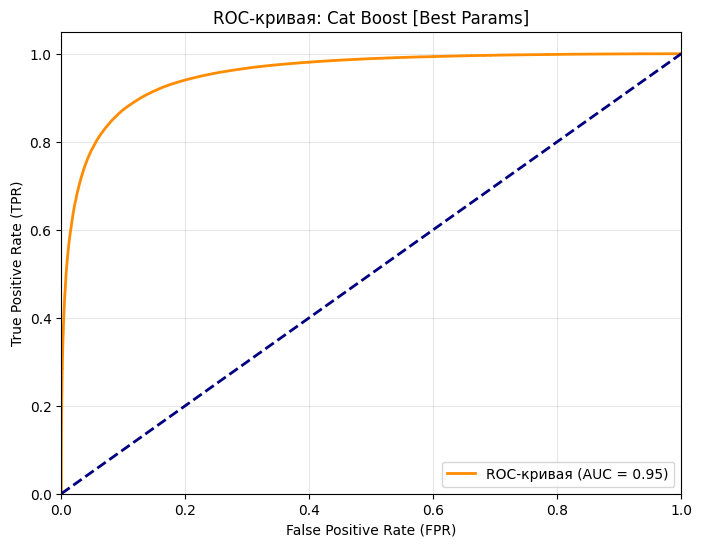

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.89      0.90      0.90    278037
           1       0.88      0.87      0.87    225963

    accuracy                           0.89    504000
   macro avg       0.89      0.89      0.89    504000
weighted avg       0.89      0.89      0.89    504000



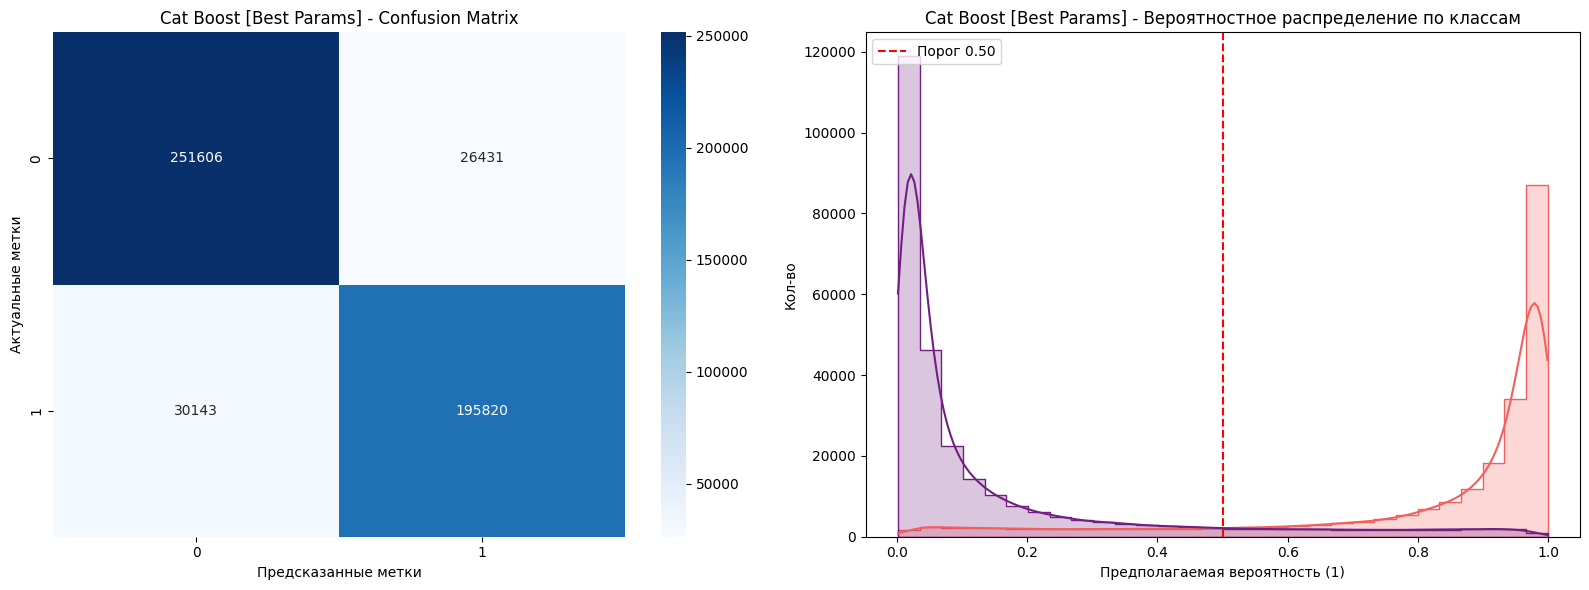

In [65]:
def build_pipeline_fn(trial):
    bootstrap_type = trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli", "MVS"])
    grow_policy = trial.suggest_categorical("grow_policy", ["SymmetricTree", "Depthwise", "Lossguide"])

    params = {
        "iterations": trial.suggest_int("iterations", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "depth": trial.suggest_int("depth", 4, 12),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-8, 100.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 1e-8, 10.0, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 100),
        "border_count": trial.suggest_int("border_count", 32, 128),
        "bootstrap_type": bootstrap_type,
        "grow_policy": grow_policy,
        "auto_class_weights": "Balanced",
        "verbose": False,
        "random_state": RANDOM_STATE,
        "task_type": "CPU",
        "thread_count": -1,
    }

    if bootstrap_type == "Bayesian":
        params["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0, 10)
    elif bootstrap_type in ["Bernoulli", "MVS"]:
        params["subsample"] = trial.suggest_float("subsample", 0.1, 1.0)

    if grow_policy == "Lossguide":
        params["max_leaves"] = trial.suggest_int("max_leaves", 16, 64)

    return CatBoostClassifier(**params)

def build_best_pipeline_fn(best_params):
    return CatBoostClassifier(**best_params)

cb_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Cat Boost [Best Params]")

[XG Boost [Baseline]] ROC-AUC: 0.9544



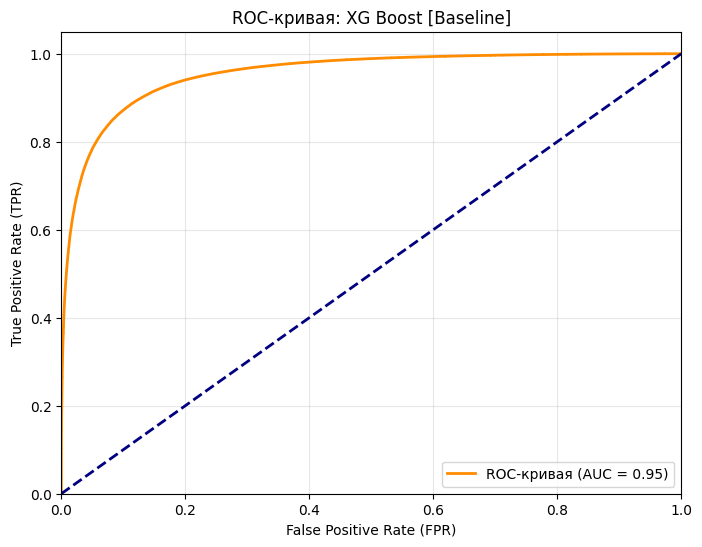

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.89      0.90      0.90    278037
           1       0.88      0.87      0.87    225963

    accuracy                           0.89    504000
   macro avg       0.89      0.89      0.89    504000
weighted avg       0.89      0.89      0.89    504000



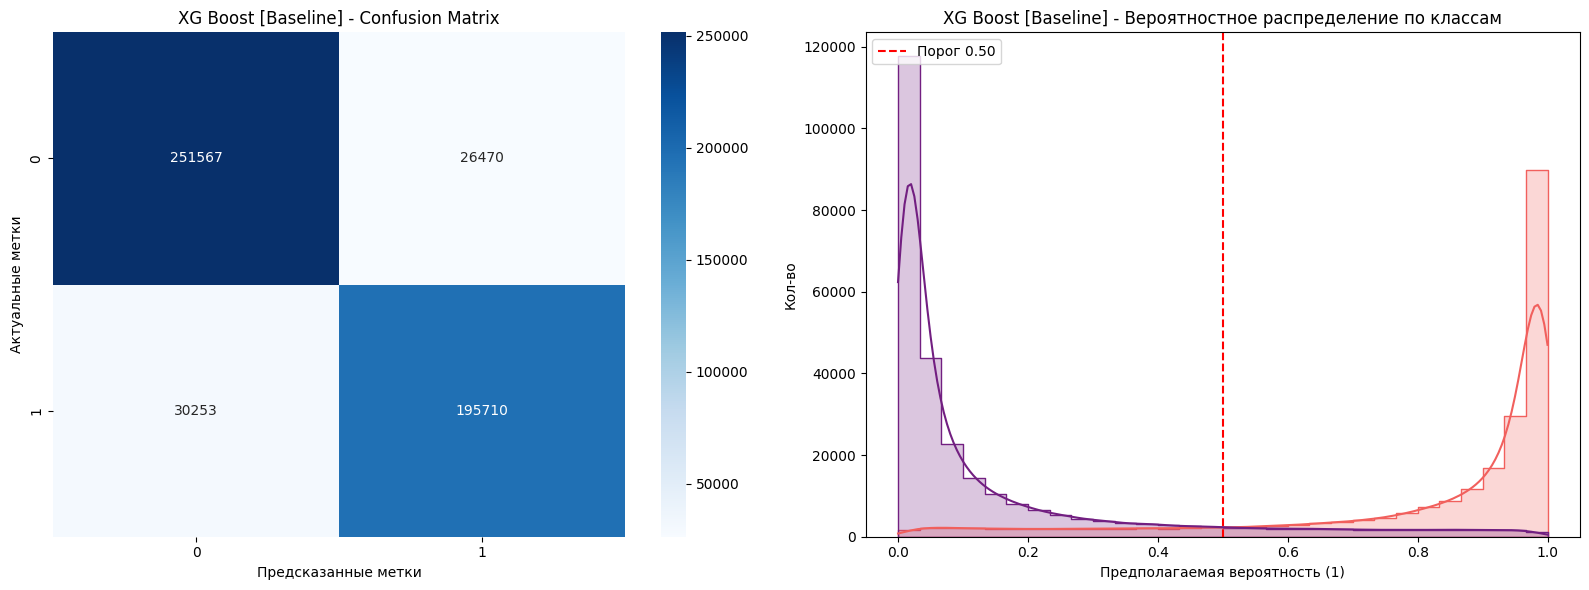

In [66]:
evaluate_model(XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1), X_train, y_train, name='XG Boost [Baseline]')

[I 2026-02-15 14:11:45,394] A new study created in memory with name: no-name-a3054f9b-b320-49ae-b64b-59030f02549d


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-02-15 14:14:06,468] Trial 0 finished with value: 0.9464418178370175 and parameters: {'n_estimators': 437, 'learning_rate': 0.22648248189516848, 'max_depth': 10, 'min_child_weight': 6, 'grow_policy': 'depthwise', 'subsample': 0.5290418060840998, 'colsample_bytree': 0.9330880728874675, 'colsample_bylevel': 0.8005575058716043, 'gamma': 3.540362888980227, 'reg_alpha': 1.5320059381854043e-08, 'reg_lambda': 5.360294728728285, 'scale_pos_weight': 8.491983767203795}. Best is trial 0 with value: 0.9464418178370175.
[I 2026-02-15 14:15:08,806] Trial 1 finished with value: 0.9463300262822619 and parameters: {'n_estimators': 291, 'learning_rate': 0.002820996133514492, 'max_depth': 4, 'min_child_weight': 4, 'grow_policy': 'depthwise', 'subsample': 0.645614570099021, 'colsample_bytree': 0.8059264473611898, 'colsample_bylevel': 0.569746930326021, 'gamma': 1.4607232426760908, 'reg_alpha': 1.9826980964985924e-05, 'reg_lambda': 0.00012724181576752517, 'scale_pos_weight': 8.066583652537123}. Best

Лучшие гиперпараметры: {'n_estimators': 696, 'learning_rate': 0.04336792818414364, 'max_depth': 9, 'min_child_weight': 6, 'grow_policy': 'lossguide', 'subsample': 0.9311936241769431, 'colsample_bytree': 0.5942049298571139, 'colsample_bylevel': 0.7134414699134696, 'gamma': 2.055752350136843, 'reg_alpha': 8.302671458616028e-05, 'reg_lambda': 3.4144383353918687e-07, 'scale_pos_weight': 4.137008029824065}
Лучшее среднее значение ROC-AUC на кросс-валидации: 0.955
[XG Boost [Best Params]] ROC-AUC: 0.9548



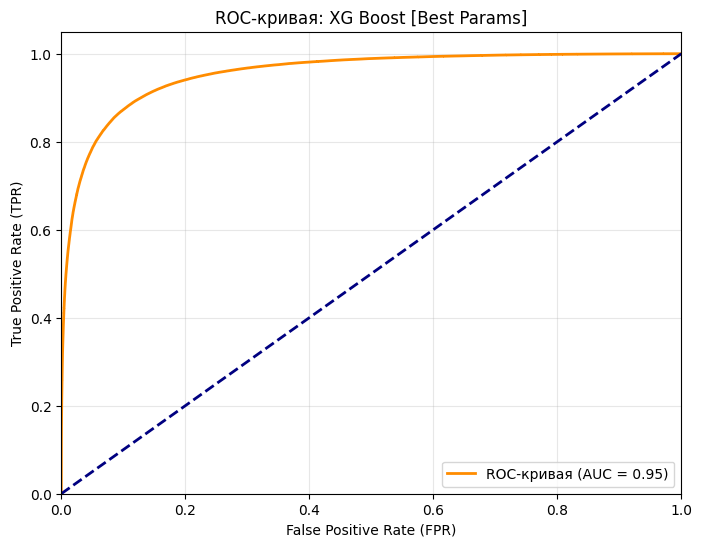

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.95      0.78      0.85    278037
           1       0.78      0.95      0.85    225963

    accuracy                           0.85    504000
   macro avg       0.86      0.86      0.85    504000
weighted avg       0.87      0.85      0.85    504000



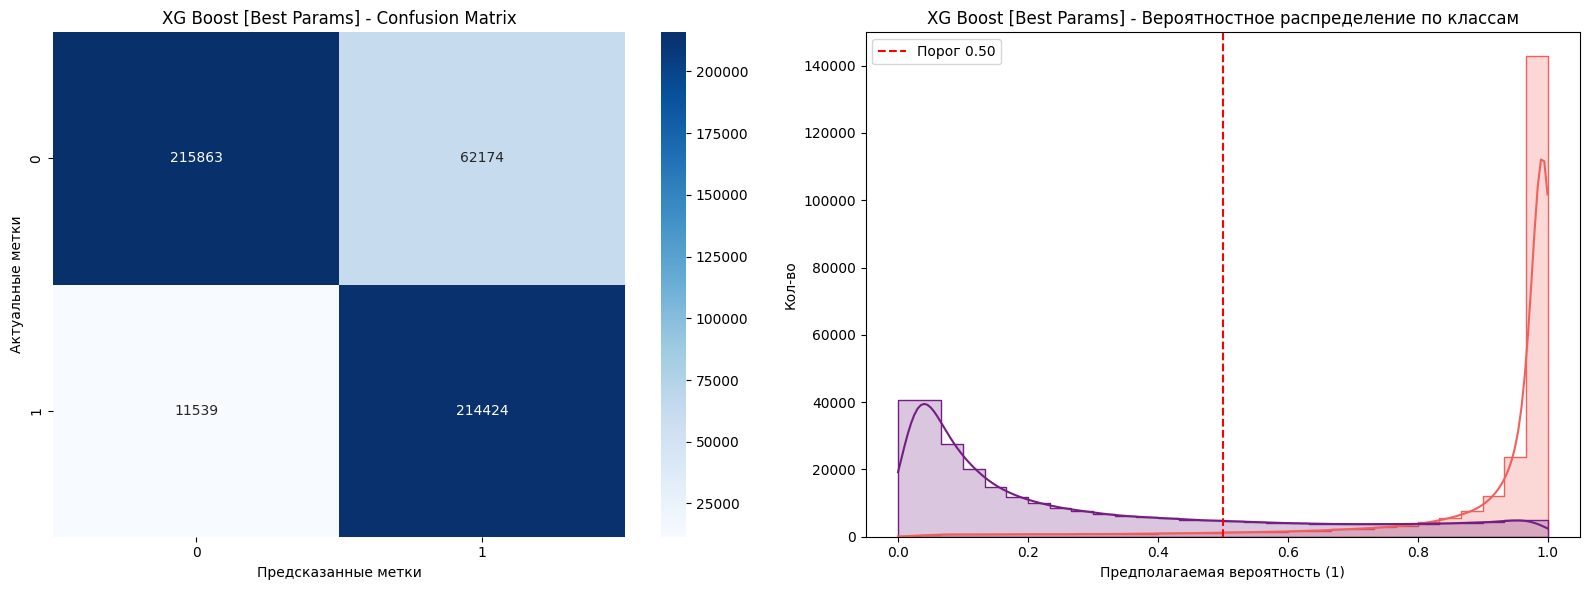

In [67]:
def build_pipeline_fn(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "grow_policy": trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"]),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 10.0),
        "booster": "gbtree",
        "tree_method": "auto",
        "objective": "binary:logistic",
        "random_state": RANDOM_STATE,
        "verbosity": 0,
        "n_jobs": -1
    }

    return XGBClassifier(**params)

def build_best_pipeline_fn(best_params):
    return XGBClassifier(**best_params)

xgb_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "XG Boost [Best Params]", n_trials=50)

[Light Boost [Baseline]] ROC-AUC: 0.9545



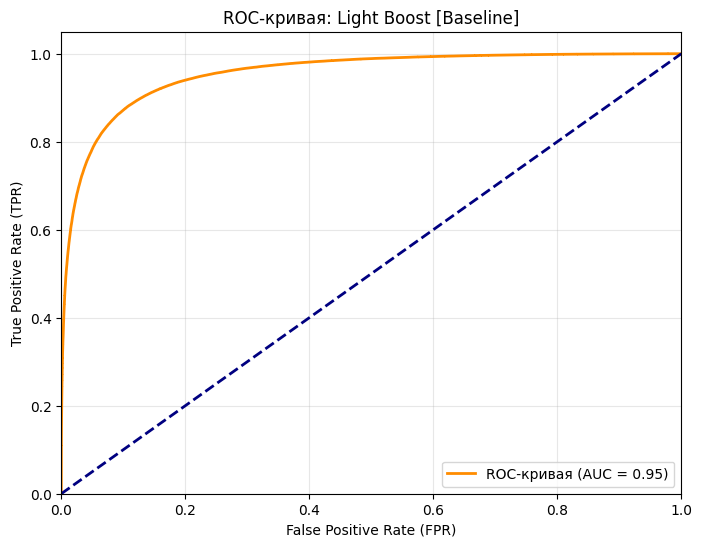

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.90      0.89      0.90    278037
           1       0.87      0.88      0.87    225963

    accuracy                           0.89    504000
   macro avg       0.89      0.89      0.89    504000
weighted avg       0.89      0.89      0.89    504000



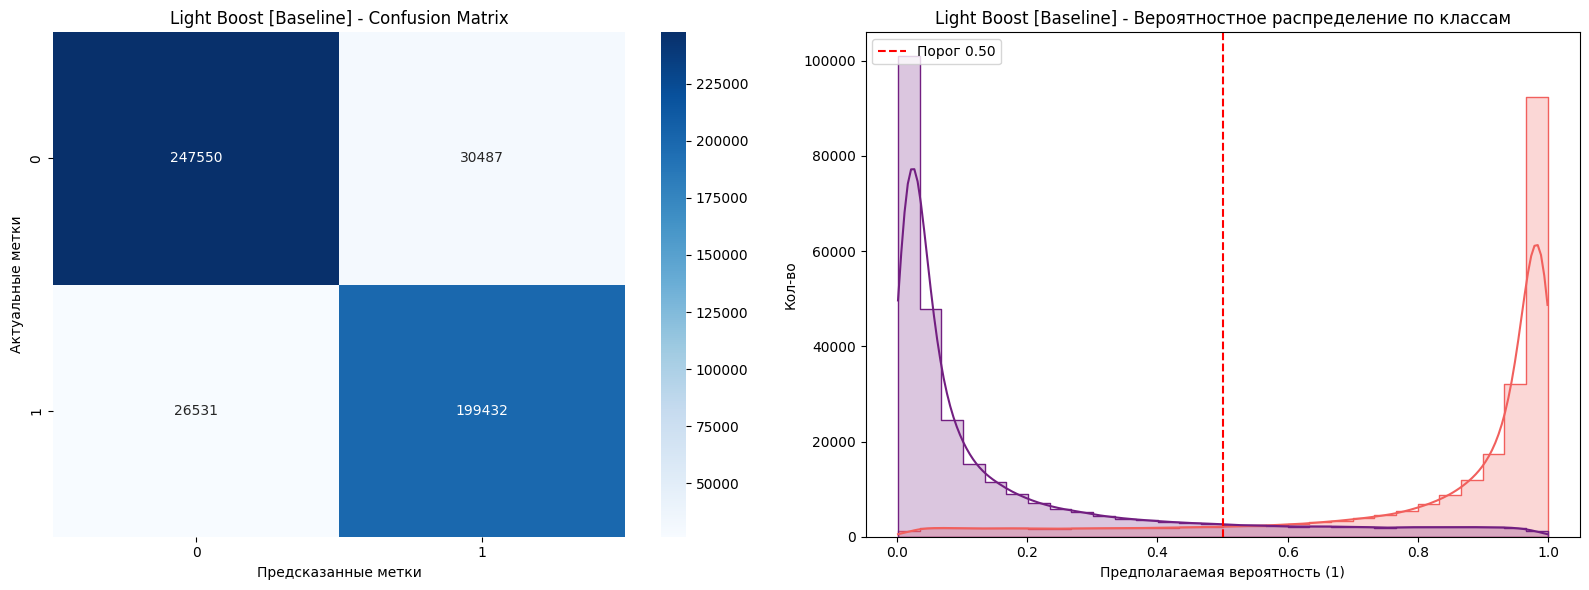

In [68]:
evaluate_model(LGBMClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1), X_train, y_train, name='Light Boost [Baseline]')

[I 2026-02-15 15:08:58,800] A new study created in memory with name: no-name-a7f2e903-cc7f-4db2-8fff-d1f41bdc0c73


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-02-15 15:09:57,312] Trial 0 finished with value: 0.9543645119266783 and parameters: {'n_estimators': 250, 'learning_rate': 0.22648248189516848, 'num_leaves': 192, 'max_depth': 8, 'min_data_in_leaf': 24, 'lambda_l1': 2.5348407664333426e-07, 'lambda_l2': 3.3323645788192616e-08, 'min_gain_to_split': 12.992642186624028, 'feature_fraction': 0.7606690070459252}. Best is trial 0 with value: 0.9543645119266783.
[I 2026-02-15 15:17:37,812] Trial 1 finished with value: 0.9531445140349225 and parameters: {'n_estimators': 383, 'learning_rate': 0.001124579825911934, 'num_leaves': 248, 'max_depth': 11, 'min_data_in_leaf': 29, 'lambda_l1': 4.329370014459266e-07, 'lambda_l2': 4.4734294104626844e-07, 'min_gain_to_split': 4.563633644393066, 'feature_fraction': 0.7148538589793427}. Best is trial 0 with value: 0.9543645119266783.
[I 2026-02-15 15:19:32,314] Trial 2 finished with value: 0.9494577677219482 and parameters: {'n_estimators': 273, 'learning_rate': 0.005265139631677754, 'num_leaves': 164

Лучшие гиперпараметры: {'n_estimators': 441, 'learning_rate': 0.08461888653361692, 'num_leaves': 85, 'max_depth': 3, 'min_data_in_leaf': 66, 'lambda_l1': 0.005373575450092792, 'lambda_l2': 1.4927751499807082e-06, 'min_gain_to_split': 1.0254313242027808, 'feature_fraction': 0.8113027648773606}
Лучшее среднее значение ROC-AUC на кросс-валидации: 0.955
[Light Boost [Best Params]] ROC-AUC: 0.9550



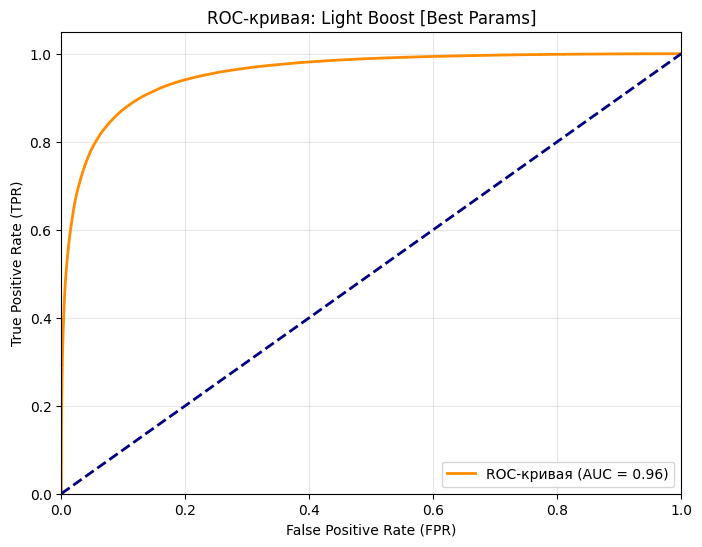

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.89      0.91      0.90    278037
           1       0.88      0.87      0.87    225963

    accuracy                           0.89    504000
   macro avg       0.89      0.89      0.89    504000
weighted avg       0.89      0.89      0.89    504000



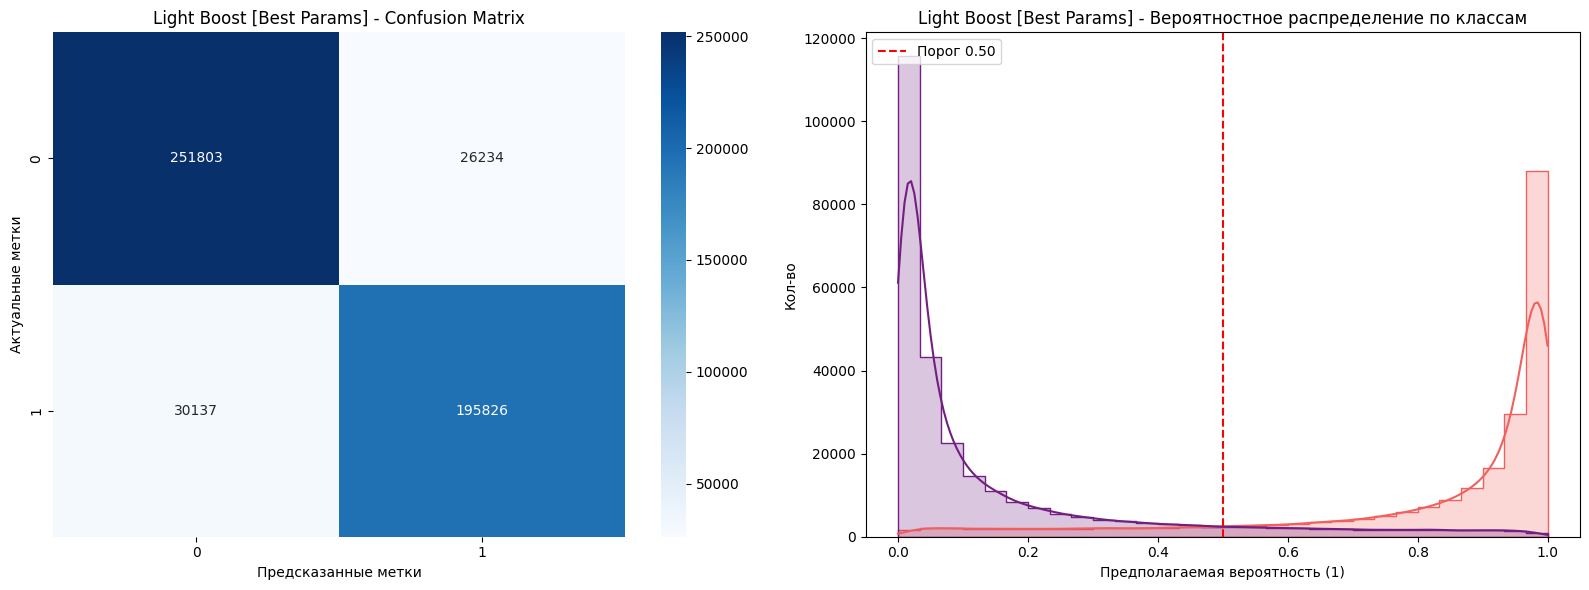

In [71]:
def build_pipeline_fn(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 255),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 100),
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
        "min_gain_to_split": trial.suggest_float("min_gain_to_split", 0, 15),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.4, 1.0),
        "boosting_type": "gbdt",
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
        "verbose": -1,
        "n_jobs": -1,
    }

    return LGBMClassifier(**params)

def build_best_pipeline_fn(best_params):
    return LGBMClassifier(**best_params)

lb_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Light Boost [Best Params]", n_trials=50)

In [72]:
lb_best_model = LGBMClassifier(**lb_best_params)
lr_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(**lr_best_params)
)
cb_best_model = CatBoostClassifier(**cb_best_params)
xgb_best_model = XGBClassifier(**xgb_best_params)
bagging_pipeline = RandomForestClassifier(**rf_best_params)

In [73]:
def run_stack(estimators, stack_name):
    meta_features = pd.DataFrame()

    print("Генерация признаков для стекинга...")

    for name, model in estimators.items():
        print(f"Обработка {name}...")
        probs = cross_val_predict(
            model,
            X_train,
            y_train,
            cv=cv,
            method='predict_proba',
            n_jobs=-1
        )[:, 1]

        meta_features[f'{name}_pred'] = probs

    print("\nMeta-features head:")
    print(meta_features.head())

    params_meta = {
        'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        'penalty': ['l1', 'l2'],
        'class_weight': 'balanced',
        'solver': 'liblinear',
    }

    grid_meta = GridSearchCV(
        LogisticRegression(random_state=RANDOM_STATE),
        params_meta,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )
    grid_meta.fit(meta_features, y_train)

    print(f"Лучшие параметры: {grid_meta.best_params_}")
    print(f"Лучший ROC-AUC после тюнинга: {grid_meta.best_score_:.5f}")

    evaluate_model(grid_meta.best_estimator_, meta_features, y_train, name=stack_name)

    plt.figure(figsize=(10, 8))
    sns.heatmap(meta_features.corr(), annot=True, cmap='coolwarm', fmt=".3f")
    plt.title("Корреляция предсказаний базовых моделей")
    plt.show()

    return grid_meta.best_params_

Генерация признаков для стекинга...
Обработка log_reg...
Обработка bagging...

Meta-features head:
   log_reg_pred  bagging_pred
0      0.980293      0.978212
1      0.156908      0.144304
2      0.984152      0.969405
3      0.936421      0.742693
4      0.108276      0.071212


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning:

'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.



Лучшие параметры: {'C': 0.001, 'penalty': 'l2'}
Лучший ROC-AUC после тюнинга: 0.95219
[Stack without boost] ROC-AUC: 0.9522



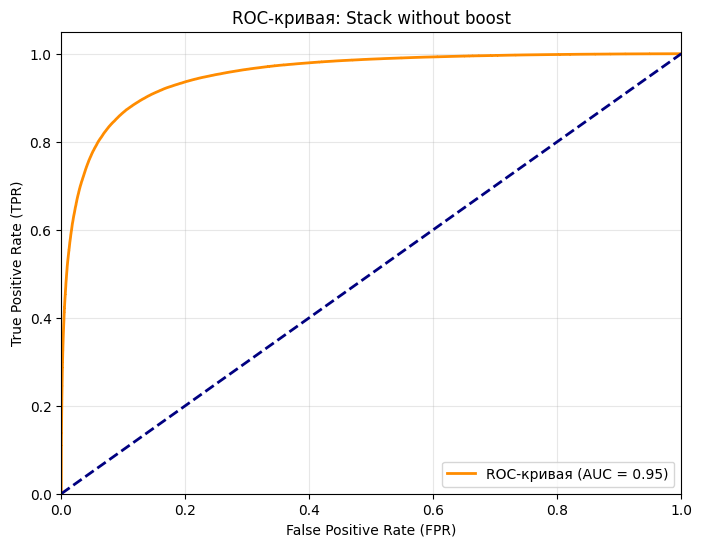

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.90      0.89      0.89    278037
           1       0.86      0.88      0.87    225963

    accuracy                           0.88    504000
   macro avg       0.88      0.88      0.88    504000
weighted avg       0.88      0.88      0.88    504000



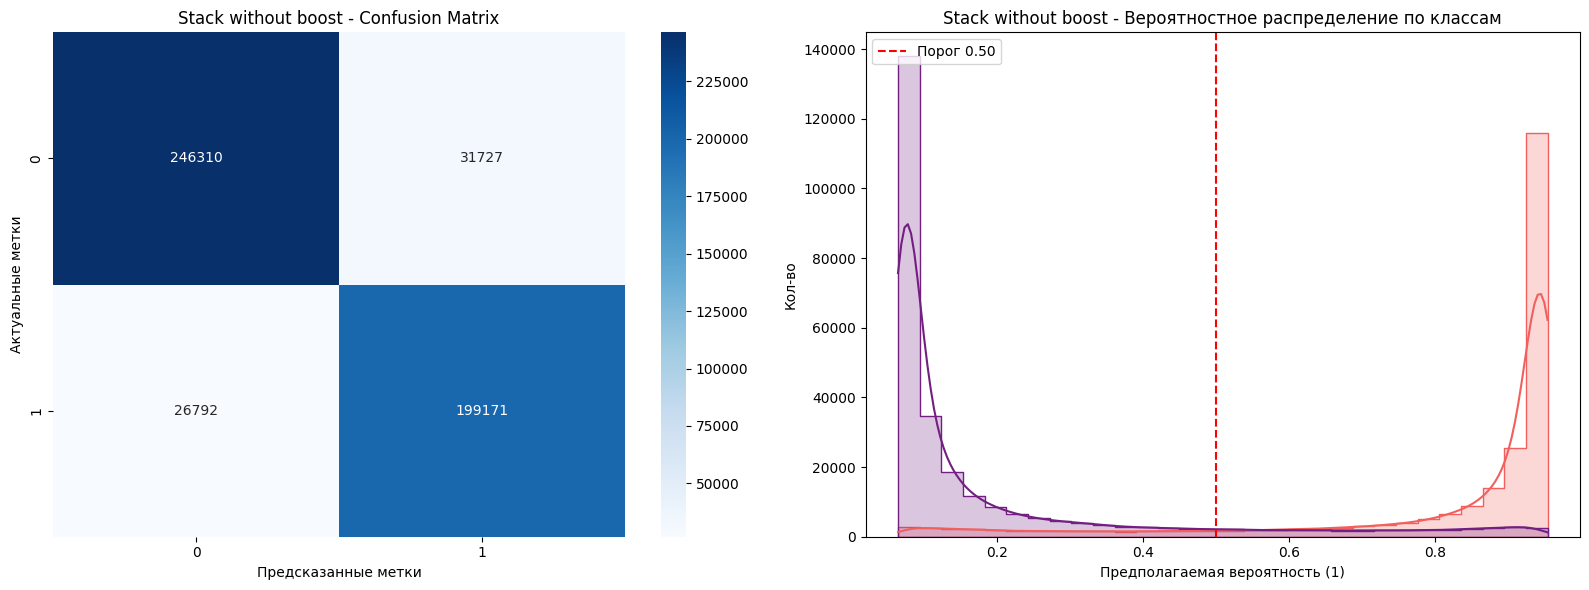

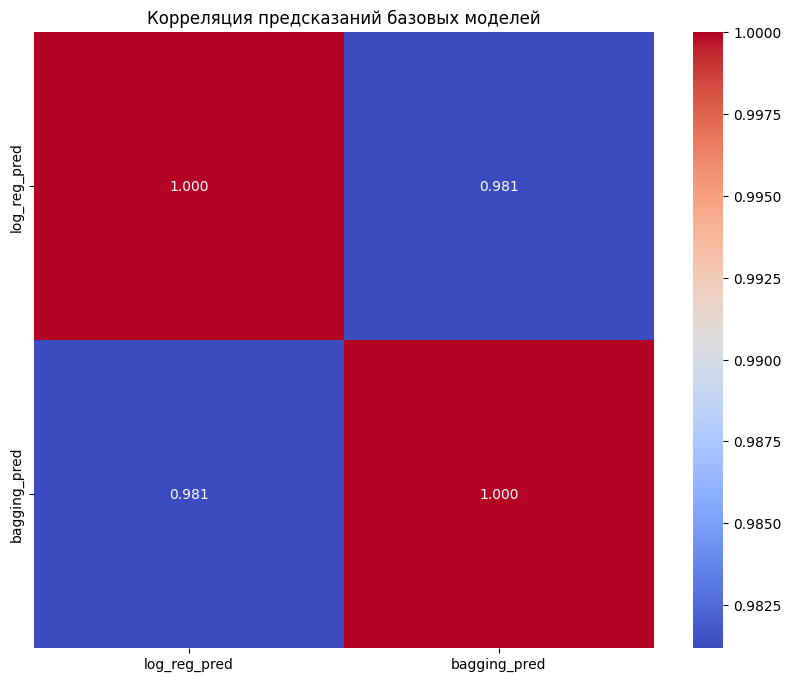

In [74]:
estimators = {
    'log_reg': lr_pipeline,
    'bagging': bagging_pipeline
}

swb_params = run_stack(estimators, stack_name='Stack without boost')

Генерация признаков для стекинга...
Обработка light_boost...
Обработка cat_boost...
Обработка xg_boost...

Meta-features head:
   light_boost_pred  cat_boost_pred  xg_boost_pred
0          0.988051        0.987530       0.997157
1          0.110142        0.115298       0.341916
2          0.969922        0.956685       0.991759
3          0.746105        0.819876       0.942569
4          0.035925        0.030790       0.096051


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning:

'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.



Лучшие параметры: {'C': 0.01, 'penalty': 'l2'}
Лучший ROC-AUC после тюнинга: 0.95508
[Stack Boost] ROC-AUC: 0.9551



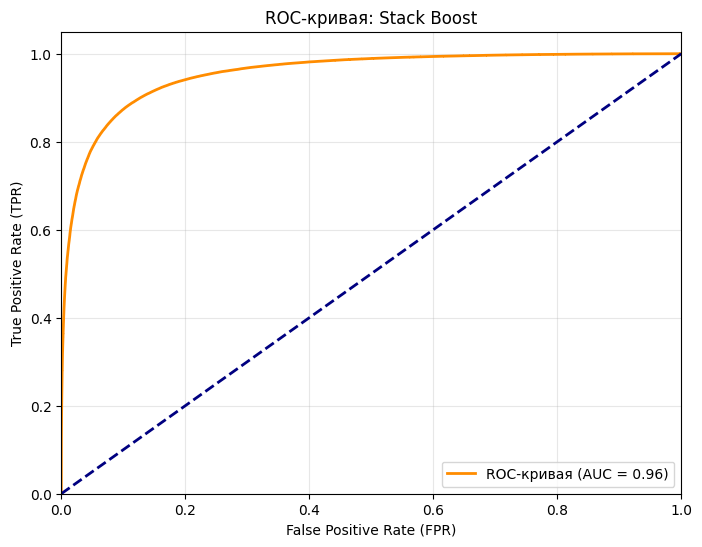

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.91      0.89      0.90    278037
           1       0.86      0.89      0.88    225963

    accuracy                           0.89    504000
   macro avg       0.89      0.89      0.89    504000
weighted avg       0.89      0.89      0.89    504000



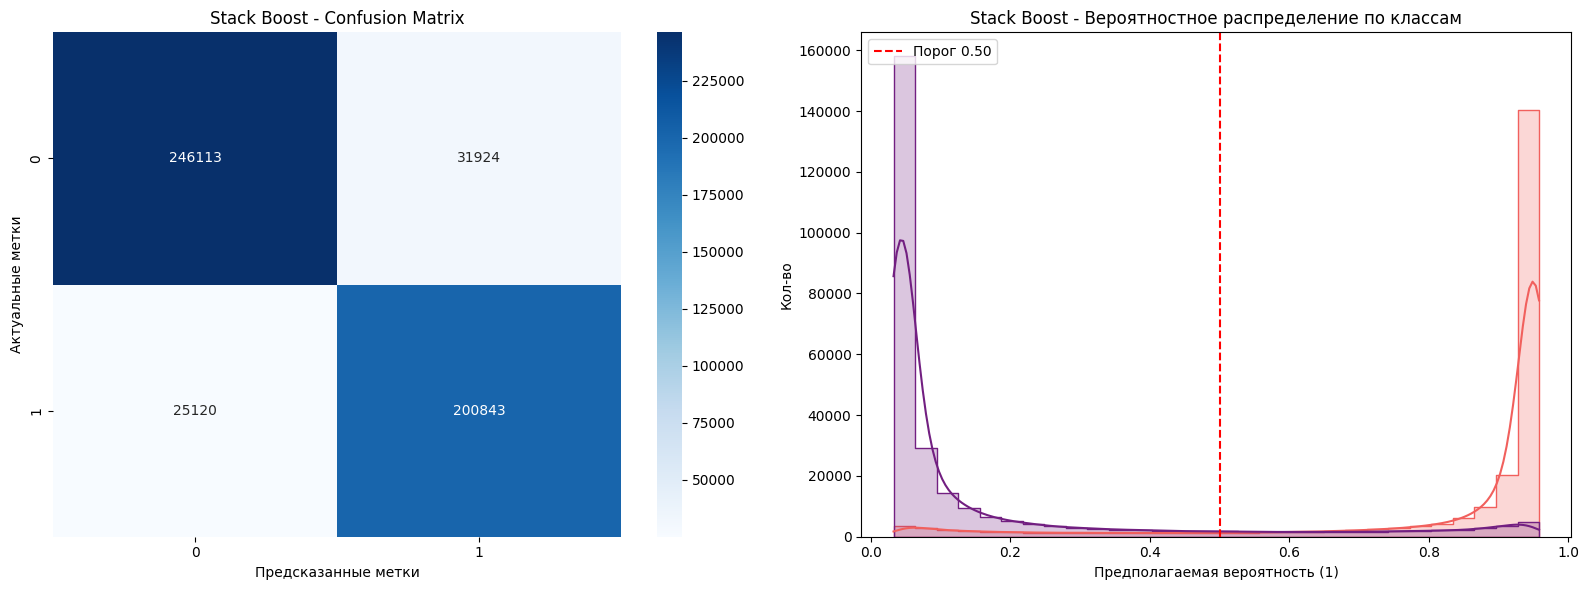

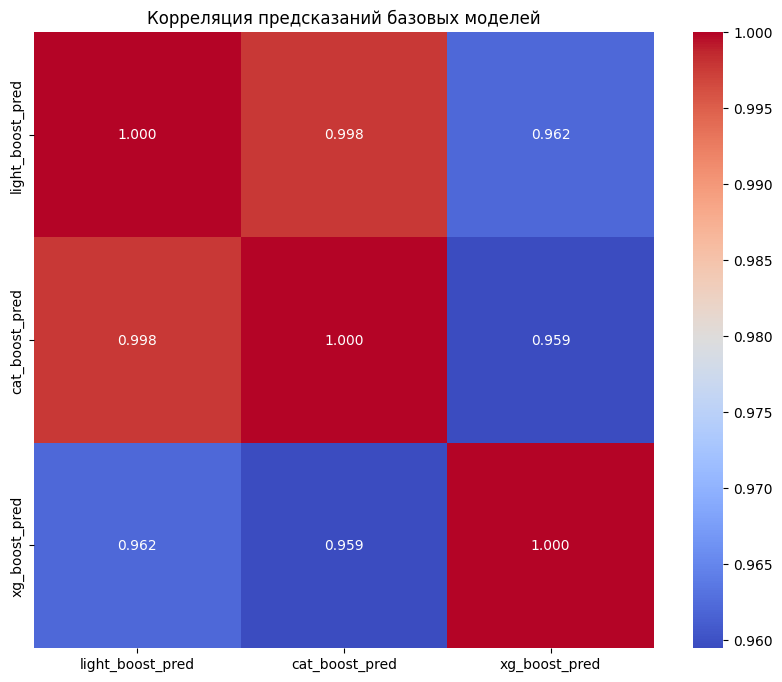

In [75]:
estimators = {
    'light_boost': lb_best_model,
    'cat_boost': cb_best_model,
    'xg_boost': xgb_best_model,
}

sb_params = run_stack(estimators, stack_name='Stack Boost')

Генерация признаков для стекинга...
Обработка light_boost...
Обработка log_reg...

Meta-features head:
   light_boost_pred  log_reg_pred
0          0.988051      0.980293
1          0.110142      0.156908
2          0.969922      0.984152
3          0.746105      0.936421
4          0.035925      0.108276


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning:

'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.



Лучшие параметры: {'C': 0.001, 'penalty': 'l1'}
Лучший ROC-AUC после тюнинга: 0.95500
[Stack TOP-2] ROC-AUC: 0.9550



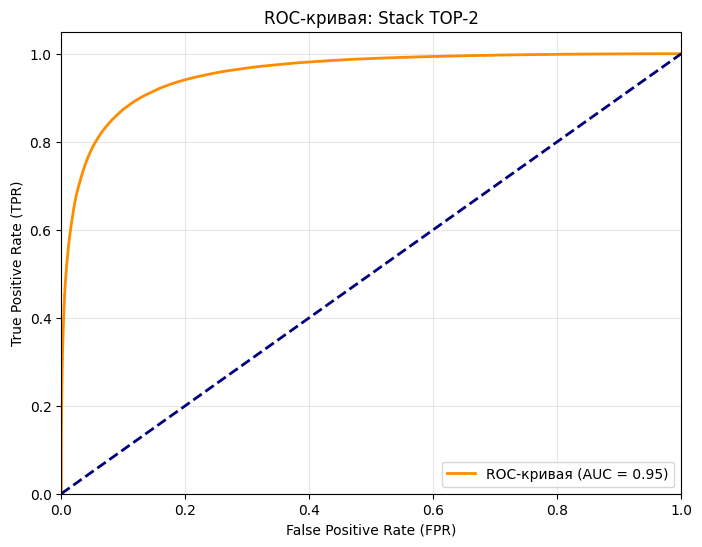

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.90      0.90      0.90    278037
           1       0.87      0.88      0.88    225963

    accuracy                           0.89    504000
   macro avg       0.89      0.89      0.89    504000
weighted avg       0.89      0.89      0.89    504000



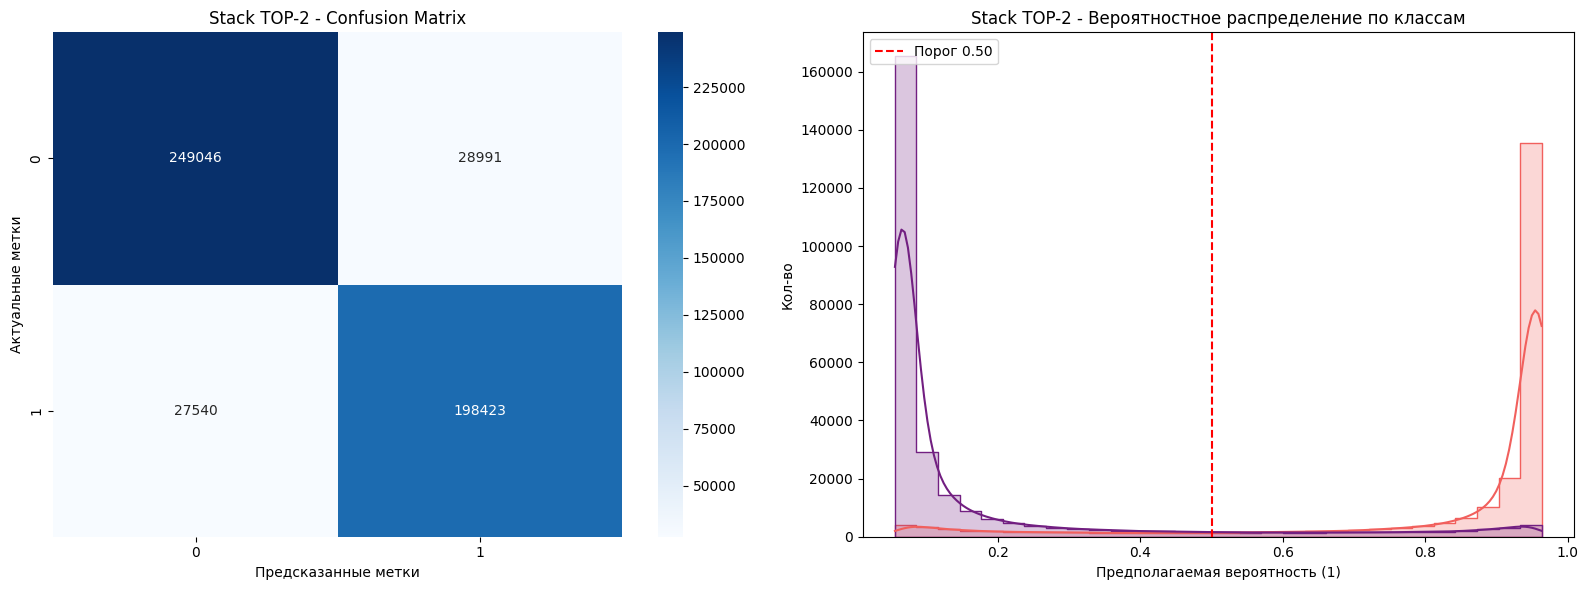

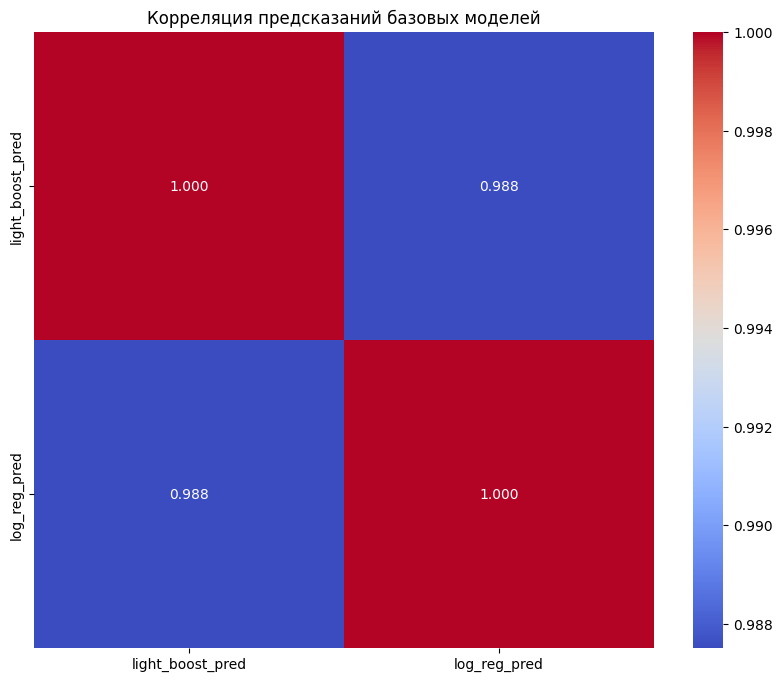

In [76]:
estimators = {
    'light_boost': lb_best_model,
    'log_reg': lr_pipeline,
}

top2_params = run_stack(estimators, stack_name='Stack TOP-2')

Генерация признаков для стекинга...
Обработка light_boost...
Обработка log_reg...
Обработка cat_boost...

Meta-features head:
   light_boost_pred  log_reg_pred  cat_boost_pred
0          0.988051      0.980293        0.987530
1          0.110142      0.156908        0.115298
2          0.969922      0.984152        0.956685
3          0.746105      0.936421        0.819876
4          0.035925      0.108276        0.030790


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning:

'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.



Лучшие параметры: {'C': 0.001, 'penalty': 'l1'}
Лучший ROC-AUC после тюнинга: 0.95500
[Stack TOP-3] ROC-AUC: 0.9550



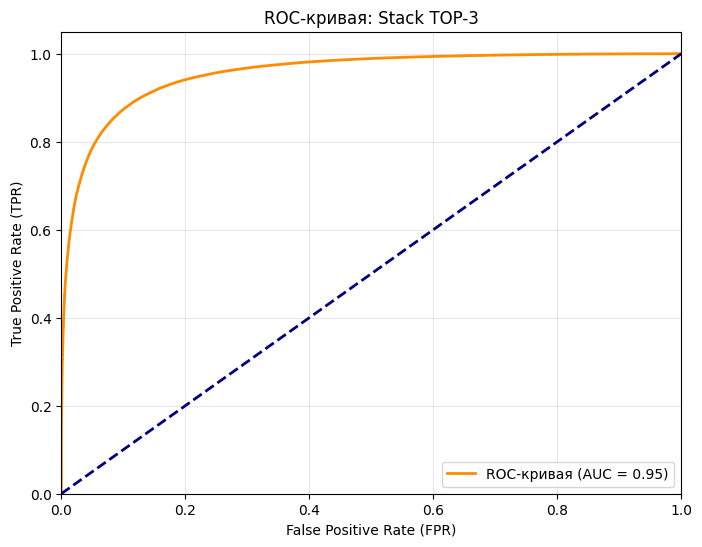

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.90      0.90      0.90    278037
           1       0.87      0.88      0.88    225963

    accuracy                           0.89    504000
   macro avg       0.89      0.89      0.89    504000
weighted avg       0.89      0.89      0.89    504000



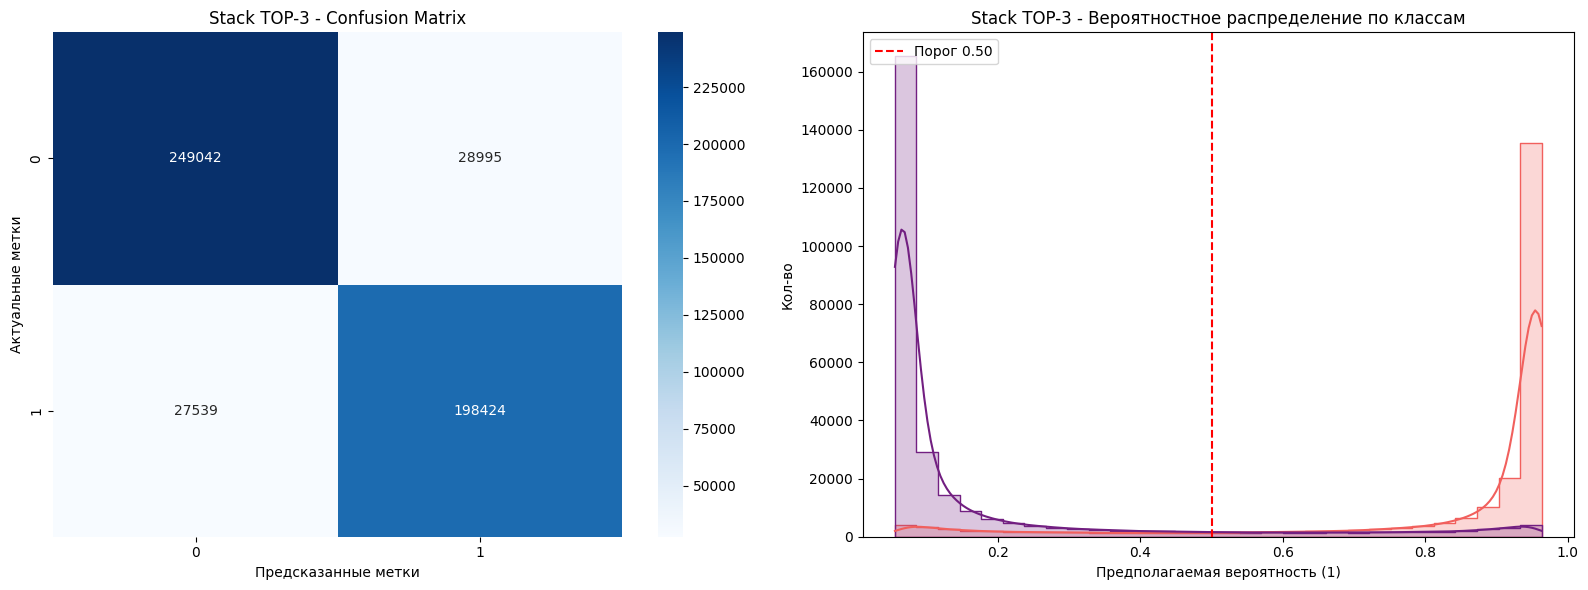

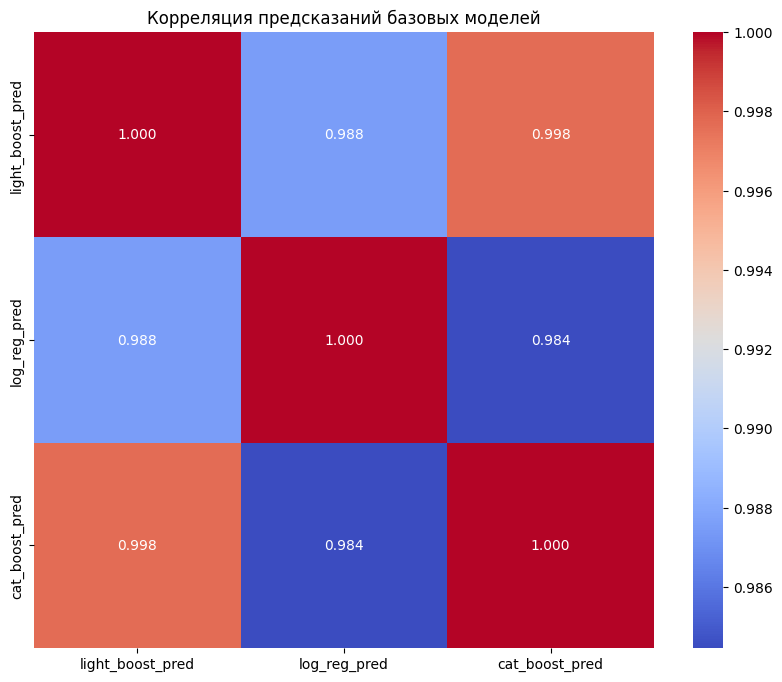

In [77]:
estimators = {
    'light_boost': lb_best_model,
    'log_reg': lr_pipeline,
    'cat_boost': cb_best_model,
}

top3_params = run_stack(estimators, stack_name='Stack TOP-3')

Генерация признаков для стекинга...
Обработка light_boost...
Обработка log_reg...
Обработка cat_boost...
Обработка xg_boost...
Обработка bagging...

Meta-features head:
   light_boost_pred  log_reg_pred  cat_boost_pred  xg_boost_pred  bagging_pred
0          0.988051      0.980293        0.987530       0.997157      0.975609
1          0.110142      0.156908        0.115298       0.341916      0.140971
2          0.969922      0.984152        0.956685       0.991759      0.963976
3          0.746105      0.936421        0.819876       0.942569      0.761828
4          0.035925      0.108276        0.030790       0.096051      0.070327


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning:

'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.



Лучшие параметры: {'C': 0.001, 'penalty': 'l1'}
Лучший ROC-AUC после тюнинга: 0.95488
[Stack TOP-5] ROC-AUC: 0.9549



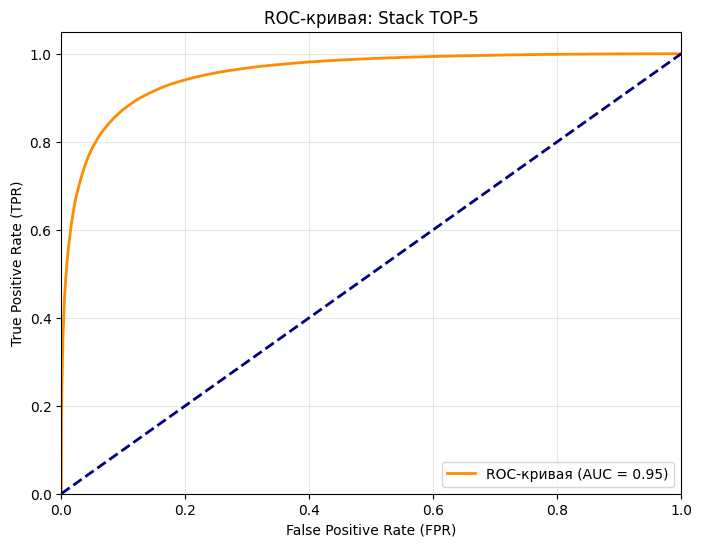

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.91      0.89      0.90    278037
           1       0.87      0.89      0.88    225963

    accuracy                           0.89    504000
   macro avg       0.89      0.89      0.89    504000
weighted avg       0.89      0.89      0.89    504000



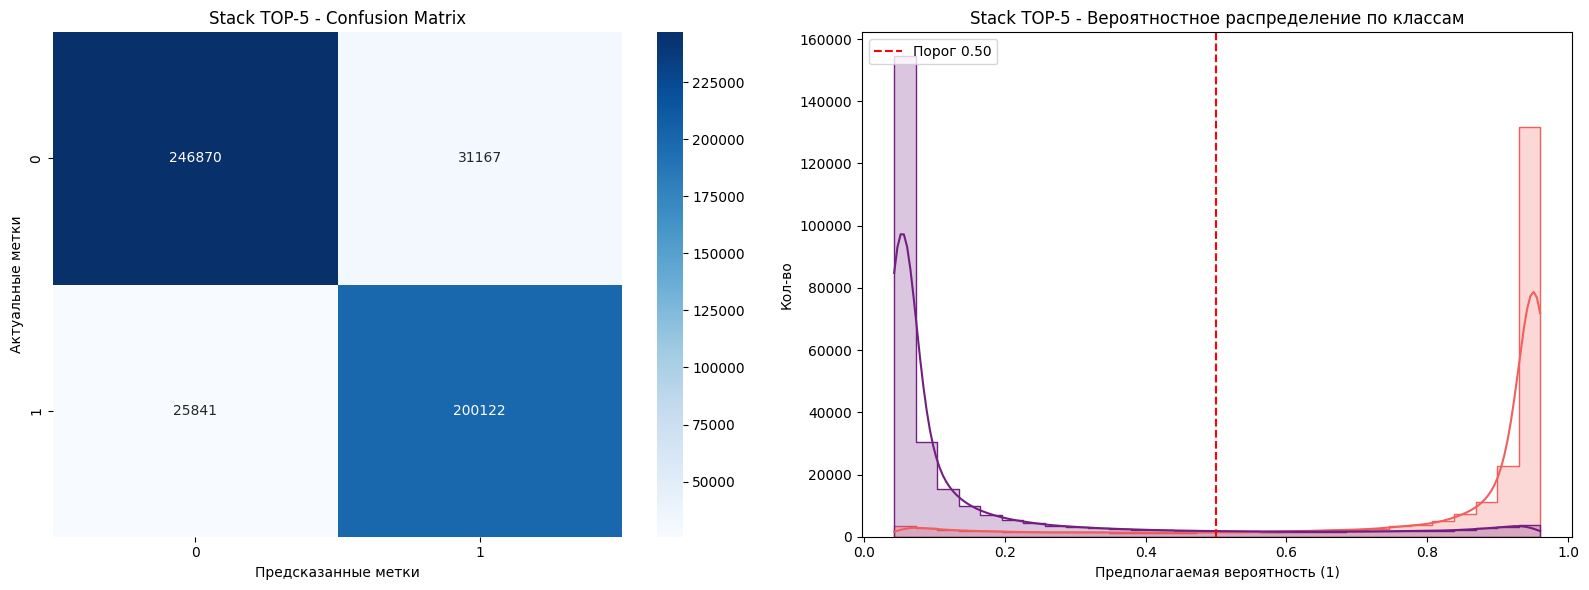

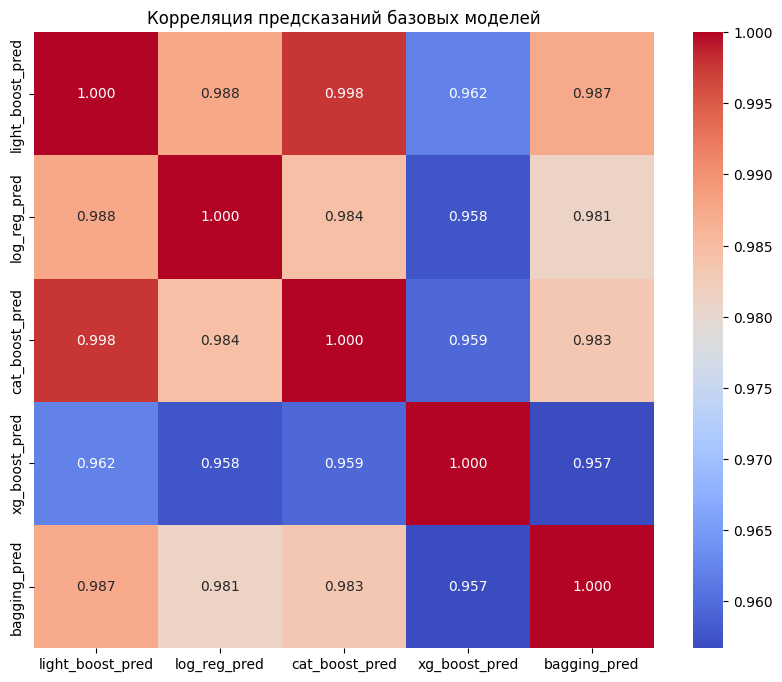

In [78]:
estimators = {
    'light_boost': lb_best_model,
    'log_reg': lr_pipeline,
    'cat_boost': cb_best_model,
    'xg_boost': xgb_best_model,
    'bagging': bagging_pipeline
}

top5_params = run_stack(estimators, stack_name='Stack TOP-5')

Генерация признаков для стекинга...
Обработка light_boost...
Обработка log_reg...
Обработка xg_boost...

Meta-features head:
   light_boost_pred  log_reg_pred  xg_boost_pred
0          0.988051      0.980293       0.997157
1          0.110142      0.156908       0.341916
2          0.969922      0.984152       0.991759
3          0.746105      0.936421       0.942569
4          0.035925      0.108276       0.096051


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning:

'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.



Лучшие параметры: {'C': 0.001, 'penalty': 'l1'}
Лучший ROC-AUC после тюнинга: 0.95507
[Stack TOP-3 corr] ROC-AUC: 0.9551



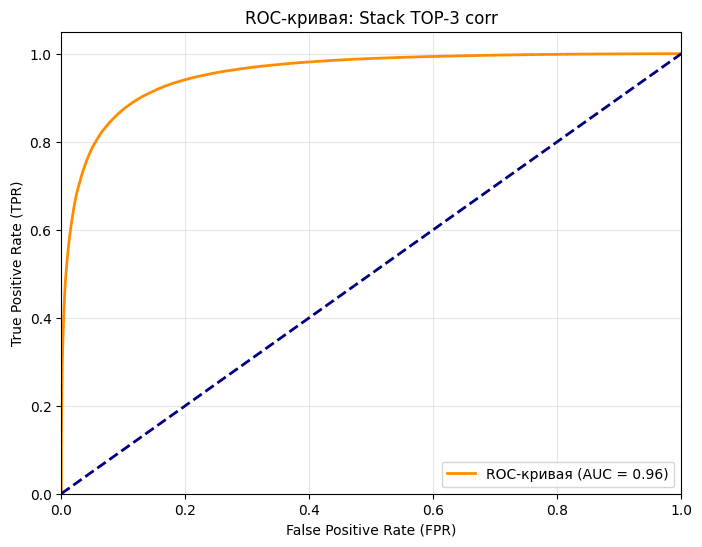

Результаты на тесте с новым порогом
              precision    recall  f1-score   support

           0       0.91      0.89      0.90    278037
           1       0.87      0.89      0.88    225963

    accuracy                           0.89    504000
   macro avg       0.89      0.89      0.89    504000
weighted avg       0.89      0.89      0.89    504000



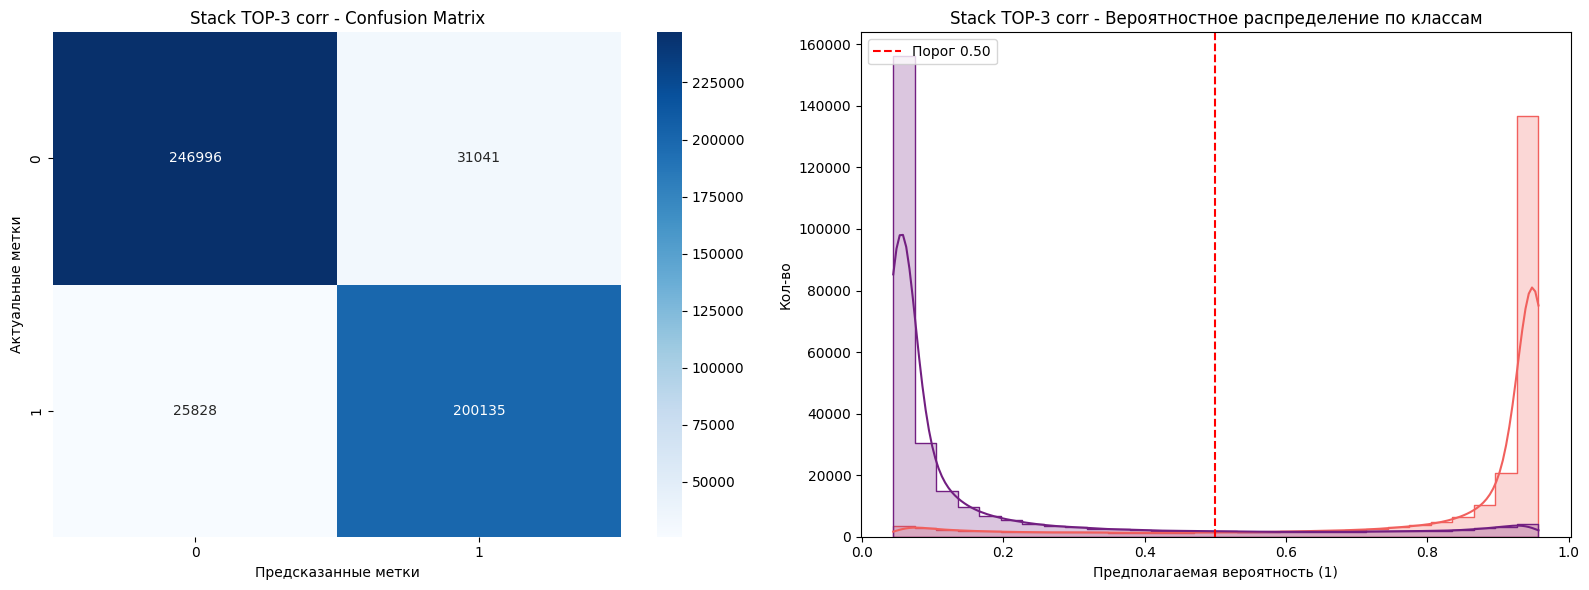

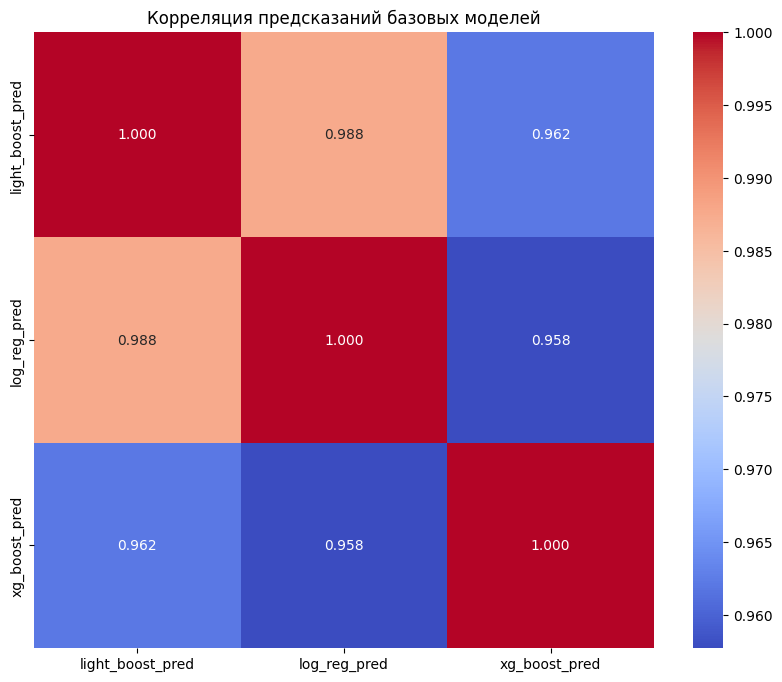

In [82]:
estimators = {
    'light_boost': lb_best_model,
    'log_reg': lr_pipeline,
    'xg_boost': xgb_best_model,
}

corr_top3_params = run_stack(estimators, stack_name='Stack TOP-3 corr')

In [83]:
pd.DataFrame(results) \
    .sort_values(by='ROC-AUC', ascending=False) \
    .style.background_gradient(cmap='coolwarm')

,Название модели,ROC-AUC
14,Stack Boost,0.955078
19,Stack TOP-3 corr,0.955064
18,Stack TOP-3 corr,0.955064
12,Light Boost [Best Params],0.955028
15,Stack TOP-2,0.954995
16,Stack TOP-3,0.954994
17,Stack TOP-5,0.954880
10,XG Boost [Best Params],0.954836
7,Cat Boost [Baseline],0.954833
8,Cat Boost [Best Params],0.954577


Финальное тестирование стекинга...
Предсказание на тесте...
[LightGBM] [Warning] min_data_in_leaf is set=66, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=66
[LightGBM] [Warning] feature_fraction is set=0.8113027648773606, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8113027648773606
[LightGBM] [Warning] lambda_l2 is set=1.4927751499807082e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.4927751499807082e-06
[LightGBM] [Warning] min_gain_to_split is set=1.0254313242027808, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=1.0254313242027808
[LightGBM] [Warning] lambda_l1 is set=0.005373575450092792, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.005373575450092792
[Test Stack TOP-3] ROC-AUC: 0.9560



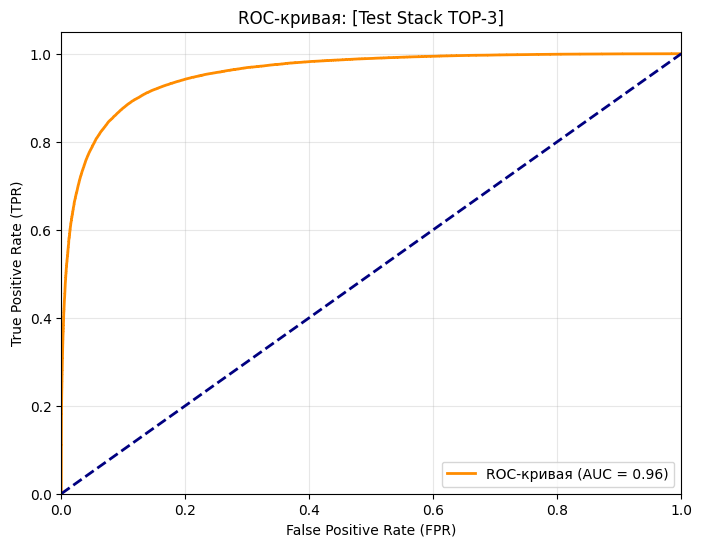

In [88]:
estimators = [
    ('light_boost', lb_best_model),
    ('log_reg', lr_pipeline),
]

top2_final_stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(**top2_params, random_state=RANDOM_STATE),
    cv=cv,
    n_jobs=-1
)

print("Финальное тестирование стекинга...")
top2_final_stack.fit(X_train, y_train)

print("Предсказание на тесте...")
y_proba = top2_final_stack.predict_proba(X_test)[:, 1]

score = roc_auc_score(y_test, y_proba)
name = '[Test Stack TOP-3]'
print(f"{name} ROC-AUC: {score:.4f}\n")
show_ROC_curve(y_test, y_proba, score, name)

Финальное тестирование стекинга...
Предсказание на тесте...
[LightGBM] [Warning] min_data_in_leaf is set=66, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=66
[LightGBM] [Warning] feature_fraction is set=0.8113027648773606, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8113027648773606
[LightGBM] [Warning] lambda_l2 is set=1.4927751499807082e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.4927751499807082e-06
[LightGBM] [Warning] min_gain_to_split is set=1.0254313242027808, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=1.0254313242027808
[LightGBM] [Warning] lambda_l1 is set=0.005373575450092792, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.005373575450092792
[Test Stack TOP-5] ROC-AUC: 0.9561



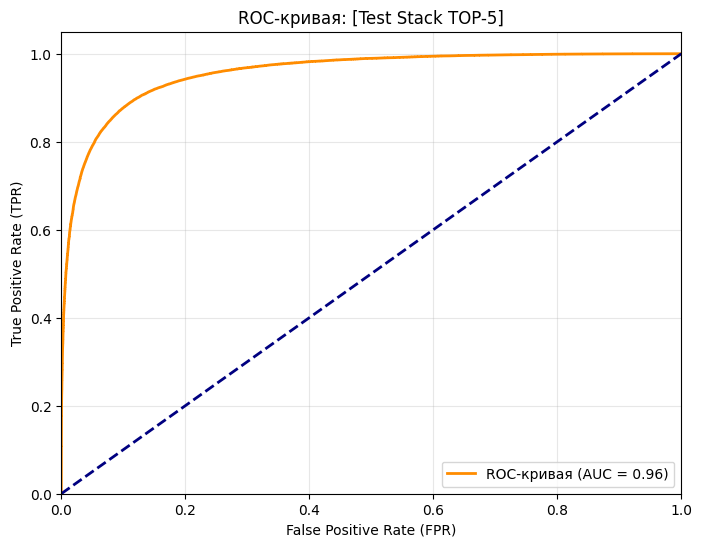

In [89]:
estimators = [
    ('light_boost', lb_best_model),
    ('cat_boost', cb_best_model),
    ('xg_boost', xgb_best_model),
]

boost_final_stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(**sb_params, random_state=RANDOM_STATE),
    cv=cv,
    n_jobs=-1
)

print("Финальное тестирование стекинга...")
boost_final_stack.fit(X_train, y_train)

print("Предсказание на тесте...")
y_proba = boost_final_stack.predict_proba(X_test)[:, 1]

score = roc_auc_score(y_test, y_proba)
name = '[Test Stack TOP-5]'
print(f"{name} ROC-AUC: {score:.4f}\n")
show_ROC_curve(y_test, y_proba, score, name)

Финальное тестирование стекинга...
Предсказание на тесте...
[LightGBM] [Warning] min_data_in_leaf is set=66, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=66
[LightGBM] [Warning] feature_fraction is set=0.8113027648773606, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8113027648773606
[LightGBM] [Warning] lambda_l2 is set=1.4927751499807082e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.4927751499807082e-06
[LightGBM] [Warning] min_gain_to_split is set=1.0254313242027808, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=1.0254313242027808
[LightGBM] [Warning] lambda_l1 is set=0.005373575450092792, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.005373575450092792
[Test Stack TOP-3 corr] ROC-AUC: 0.9560



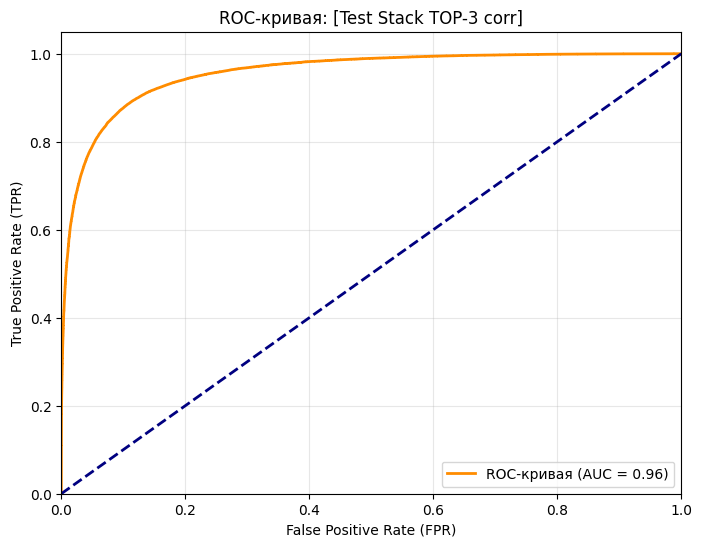

In [90]:
estimators = [
    ('light_boost', lb_best_model),
    ('log_reg', lr_pipeline),
    ('xg_boost', xgb_best_model)
]

top3_corr_final_stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(**corr_top3_params, random_state=RANDOM_STATE),
    cv=cv,
    n_jobs=-1
)

print("Финальное тестирование стекинга...")
top3_corr_final_stack.fit(X_train, y_train)

print("Предсказание на тесте...")
y_proba = top3_corr_final_stack.predict_proba(X_test)[:, 1]

score = roc_auc_score(y_test, y_proba)
name = '[Test Stack TOP-3 corr]'
print(f"{name} ROC-AUC: {score:.4f}\n")
show_ROC_curve(y_test, y_proba, score, name)

In [93]:
test = get_df('./datasets/test.csv')

X_kaggle = test.drop(columns=['id'])

In [94]:
from google.colab import files

top2_final_stack.fit(X, y)
top2_submission_proba = top3_corr_final_stack.predict_proba(X_kaggle)[:, 1]
submission = pd.DataFrame({
    'id': test['id'],
    'Heart Disease': top2_submission_proba
})
submission.to_csv('datasets/submission1.csv', index=False)
files.download('datasets/submission1.csv')

boost_final_stack.fit(X, y)
boost_submission_proba = top3_corr_final_stack.predict_proba(X_kaggle)[:, 1]
submission = pd.DataFrame({
    'id': test['id'],
    'Heart Disease': boost_submission_proba
})
submission.to_csv('datasets/submission2.csv', index=False)
files.download('datasets/submission2.csv')

top3_corr_final_stack.fit(X, y)
top3_submission_proba = top3_corr_final_stack.predict_proba(X_kaggle)[:, 1]
submission = pd.DataFrame({
    'id': test['id'],
    'Heart Disease': top3_submission_proba
})
submission.to_csv('datasets/submission3.csv', index=False)
files.download('datasets/submission3.csv')

[LightGBM] [Warning] min_data_in_leaf is set=66, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=66
[LightGBM] [Warning] feature_fraction is set=0.8113027648773606, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8113027648773606
[LightGBM] [Warning] lambda_l2 is set=1.4927751499807082e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.4927751499807082e-06
[LightGBM] [Warning] min_gain_to_split is set=1.0254313242027808, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=1.0254313242027808
[LightGBM] [Warning] lambda_l1 is set=0.005373575450092792, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.005373575450092792


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



[LightGBM] [Warning] min_data_in_leaf is set=66, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=66
[LightGBM] [Warning] feature_fraction is set=0.8113027648773606, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8113027648773606
[LightGBM] [Warning] lambda_l2 is set=1.4927751499807082e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.4927751499807082e-06
[LightGBM] [Warning] min_gain_to_split is set=1.0254313242027808, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=1.0254313242027808
[LightGBM] [Warning] lambda_l1 is set=0.005373575450092792, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.005373575450092792
[LightGBM] [Warning] min_data_in_leaf is set=66, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=66
[LightGBM] [Warning] feature_fraction is set=0.8113027648773606, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8113027648773606
[LightGBM] [War